# Pakistan Housing Market — Exploratory Data Analysis

An in-depth exploration of **16,000+ property listings** from [Zameen.com](https://www.zameen.com/), Pakistan's largest real estate marketplace. This analysis examines pricing patterns, geographic trends, and property characteristics across 12 major Pakistani cities to uncover actionable insights for real estate investors and market analysts.

**Dataset:** Zameen.com Housing Prices (Kaggle)  
**Tools:** Python, pandas, matplotlib, seaborn, plotly

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization defaults
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 150

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
df = pd.read_csv('../data/raw/archive_2/zameen.csv', sep='|')
print(f'Dataset: {df.shape[0]:,} listings \u00d7 {df.shape[1]} features')

Dataset: 16,044 listings × 6 features


## 2. Initial Exploration

### 2.1 Sample Listings

In [3]:
df.head(10)

,city,location,price,bedrooms,baths,size
0,Lahore,"DHA Phase 6, DHA Defence",74500000,5,6,"4,500.00"
1,Lahore,"DHA Phase 7, DHA Defence",51500000,5,6,"4,500.00"
2,Lahore,"Dream Gardens, Defence Road",7500000,1,1,518.00
3,Lahore,"DHA Phase 6, DHA Defence",73000000,5,6,"4,500.00"
4,Lahore,"Bahria Town - Sector B, Bahria Town",5700000,1,1,472.00
5,Lahore,"DHA Phase 5 - Block L, DHA Phase 5",53500000,5,6,"2,250.00"
6,Lahore,"Bahria Town - Overseas A, Bahria Town - Overse...",97500000,5,6,"4,500.00"
7,Lahore,"Bahria Town - Jasmine Block, Bahria Town - Sec...",47000000,5,7,"4,500.00"
8,Lahore,"Bahria Town - Sector E, Bahria Town",5000000,1,1,450.00
9,Lahore,"Raiwind Road, Lahore",8299000,1,1,630.00


### 2.2 Data Types & Memory

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16044 entries, 0 to 16043
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   city      16044 non-null  str    
 1   location  16044 non-null  str    
 2   price     16044 non-null  int64  
 3   bedrooms  16044 non-null  int64  
 4   baths     16044 non-null  int64  
 5   size      16044 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 752.2 KB


### 2.3 Numerical Summary

In [5]:
df.describe()

,price,bedrooms,baths,size
count,"16,044.00","16,044.00","16,044.00","16,044.00"
mean,"45,711,134.19",3.78,4.06,"2,540.64"
std,"85,041,953.69",1.99,2.14,"10,607.07"
min,"70,000.00",0.00,0.00,0.00
25%,"14,000,000.00",3.00,3.00,"1,125.00"
50%,"24,000,000.00",4.00,4.00,"1,575.00"
75%,"45,000,000.00",5.00,6.00,"2,700.00"
max,"2,100,000,000.00",11.00,10.00,"1,215,000.00"


### 2.4 Categorical Summary

In [6]:
df.describe(include='object')

C:\Users\Pc\AppData\Local\Temp\ipykernel_13132\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,city,location
count,16044,16044
unique,12,2038
top,Lahore,"DHA Villas, DHA Defence"
freq,2500,481


### 2.5 First Impressions

- **16,044 listings** across **12 cities** and **2,038 unique locations** — a broad snapshot of Pakistan's urban housing market
- **No missing values** in any column, though data quality issues exist (zero-size properties, extreme outliers)
- **Price range** spans 70,000 PKR to 2.1 Billion PKR — the high end likely includes commercial or incorrectly entered listings
- **Median price** (24M PKR) is roughly half the mean (45.7M PKR), indicating strong right-skew typical of real estate markets
- **Lahore dominates** with the highest listing count, followed by DHA/Bahria Town locations — Pakistan's premium housing societies
- **Size column** contains zero values and an extreme max of 1.2M sq ft — cleaning required before analysis

## 3. Data Quality Investigation

### 3.1 Missing Values Check

In [7]:
# Count missing values per column and show as both count and percentage
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print('=== Missing Values Summary ===\n')
print(missing_summary.to_string())
print(f'\nTotal cells in dataset: {df.shape[0] * df.shape[1]:,}')
print(f'Total missing cells: {missing_count.sum():,}')

=== Missing Values Summary ===

          Missing Count  Missing %
city                  0       0.00
location              0       0.00
price                 0       0.00
bedrooms              0       0.00
baths                 0       0.00
size                  0       0.00

Total cells in dataset: 96,264
Total missing cells: 0


In [8]:
# Check for "hidden" missing values — zeros that likely represent missing data
print('=== Suspicious Zero Values ===\n')
for col in ['price', 'bedrooms', 'baths', 'size']:
    zero_count = (df[col] == 0).sum()
    zero_pct = (df[col] == 0).mean() * 100
    print(f'{col:>10}: {zero_count:,} zeros ({zero_pct:.2f}%)')

print('\n--- Interpretation ---')
print('A property with 0 size or 0 price is almost certainly a data entry error.')
print('Zero bedrooms could mean a studio/plot, but worth investigating.')

=== Suspicious Zero Values ===

     price: 0 zeros (0.00%)
  bedrooms: 1,620 zeros (10.10%)
     baths: 1,775 zeros (11.06%)
      size: 151 zeros (0.94%)

--- Interpretation ---
A property with 0 size or 0 price is almost certainly a data entry error.
Zero bedrooms could mean a studio/plot, but worth investigating.


In [9]:
# Are zero-bedroom and zero-bath listings the same rows?
both_zero = ((df['bedrooms'] == 0) & (df['baths'] == 0)).sum()
only_beds_zero = ((df['bedrooms'] == 0) & (df['baths'] != 0)).sum()
only_baths_zero = ((df['bedrooms'] != 0) & (df['baths'] == 0)).sum()

print('=== Zero Beds vs Zero Baths Overlap ===\n')
print(f'Both bedrooms AND baths = 0:  {both_zero:,}')
print(f'Only bedrooms = 0:            {only_beds_zero:,}')
print(f'Only baths = 0:               {only_baths_zero:,}')

print(f'\n--- Sample of 0-bedroom, 0-bath listings ---\n')
df[(df['bedrooms'] == 0) & (df['baths'] == 0)].sample(10, random_state=42)

=== Zero Beds vs Zero Baths Overlap ===

Both bedrooms AND baths = 0:  1,546
Only bedrooms = 0:            74
Only baths = 0:               229

--- Sample of 0-bedroom, 0-bath listings ---



,city,location,price,bedrooms,baths,size
14743,Murree,"Mall Road, Murree",13100000,0,0,"1,328.00"
9141,Multan,"Shah Rukn-e-Alam Colony - Block F, Shah Rukn-e...",4500000,0,0,675.00
12248,Rawalpindi,"Wakeel Colony, Islamabad Highway",7800000,0,0,900.00
9053,Multan,"Wapda Town Phase 1 - Block E, Wapda Town Phase 1",50000000,0,0,"4,500.00"
10728,Faisalabad,"Millat Town, Faisalabad",8000000,0,0,"1,125.00"
9864,Faisalabad,"Green Town, Faisalabad",15000000,0,0,"1,238.00"
15815,Gujranwala,"Rachna Pearl Hotel, GT Road",8198000,0,0,0.00
15017,Gujranwala,"Al-Mansoora Housing Society, Rahwali Cantt",15000000,0,0,"1,125.00"
11510,Peshawar,"Hayatabad Heights, Hayatabad Phase 3",12000000,0,0,0.00
11256,Peshawar,"Shoba Bazar, Peshawar",2392000,0,0,202.00


### 3.2 Column-by-Column Investigation

In [10]:
# City distribution — how many listings per city?
print('=== City Distribution ===\n')
city_counts = df['city'].value_counts()
print(city_counts)
print(f'\nTotal unique cities: {df["city"].nunique()}')

=== City Distribution ===

city
Lahore        2500
Karachi       2500
Rawalpindi    2500
Islamabad     2497
Multan        1923
Peshawar      1377
Faisalabad    1310
Gujranwala    1221
Murree         164
2_FECHS         25
Quetta          20
Attock           7
Name: count, dtype: int64



Total unique cities: 12


In [11]:
# Location — top 20 most common locations
print('=== Top 20 Locations ===\n')
print(df['location'].value_counts().head(20))
print(f'\nTotal unique locations: {df["location"].nunique()}')

=== Top 20 Locations ===

location
DHA Villas, DHA Defence                                                 481
Citi Housing Society, Gujranwala                                        453
Bahria Town Phase 8, Bahria Town Rawalpindi                             432
DHA Phase 6, DHA Defence                                                351
Warsak Road, Peshawar                                                   345
DHA Defence, Gujranwala                                                 343
Al-Ahad Heights, Defence Road                                           282
Buch Executive Villas, Multan                                           281
G-13, Islamabad                                                         220
Askari 5 - Sector J, Askari 5                                           205
Bahria Town Phase 8 - Ali Block, Bahria Town Phase 8 - Safari Valley    188
DHA Phase 7, DHA Defence                                                158
DHA Defence Phase 2, DHA Defence                     

In [12]:
# Bedrooms distribution
print('=== Bedrooms Distribution ===\n')
print(df['bedrooms'].value_counts().sort_index())
print(f'\nUnique values: {df["bedrooms"].nunique()}')

=== Bedrooms Distribution ===

bedrooms
0     1620
1      600
2     1413
3     3114
4     2776
5     3961
6     1664
7      523
8      208
9       73
10      67
11      25
Name: count, dtype: int64

Unique values: 12


In [13]:
# Baths distribution
print('=== Baths Distribution ===\n')
print(df['baths'].value_counts().sort_index())
print(f'\nUnique values: {df["baths"].nunique()}')

=== Baths Distribution ===

baths
0     1775
1      726
2     1232
3     1711
4     2788
5     2732
6     4093
7      657
8      241
9       34
10      55
Name: count, dtype: int64

Unique values: 11


In [14]:
# Price — key percentiles and extreme values
print('=== Price Investigation ===\n')
print(f'Min:    {df["price"].min():>20,.0f} PKR')
print(f'1st %:  {df["price"].quantile(0.01):>20,.0f} PKR')
print(f'5th %:  {df["price"].quantile(0.05):>20,.0f} PKR')
print(f'Median: {df["price"].median():>20,.0f} PKR')
print(f'95th %: {df["price"].quantile(0.95):>20,.0f} PKR')
print(f'99th %: {df["price"].quantile(0.99):>20,.0f} PKR')
print(f'Max:    {df["price"].max():>20,.0f} PKR')

print(f'\n--- Top 10 most expensive listings ---\n')
df.nlargest(10, 'price')[['city', 'location', 'price', 'bedrooms', 'size']]

=== Price Investigation ===

Min:                  70,000 PKR
1st %:             3,500,000 PKR
5th %:             6,500,000 PKR
Median:           24,000,000 PKR
95th %:          130,000,000 PKR
99th %:          460,000,000 PKR
Max:           2,100,000,000 PKR

--- Top 10 most expensive listings ---



,city,location,price,bedrooms,size
7186,Islamabad,"F-6/3, F-6",2100000000,5,"24,300.00"
739,Lahore,"Main Boulevard Gulberg, Gulberg",2000000000,11,"36,000.00"
5776,Islamabad,"F-6/2, F-6",1800000000,8,"18,000.00"
7483,Islamabad,"F-6, Islamabad",1650000000,7,"28,800.00"
6706,Islamabad,"F-7/2, F-7",1620000000,11,"18,000.00"
5701,Islamabad,"F-7/2, F-7",1600000000,0,"18,000.00"
6579,Islamabad,"F-6/2, F-6",1500000000,5,"22,500.00"
7130,Islamabad,"F-6, Islamabad",1350000000,9,"22,500.00"
7354,Islamabad,"F-6/3, F-6",1200000000,9,"18,000.00"
5648,Islamabad,"F-6, Islamabad",1100000000,4,"21,600.00"


In [15]:
# Size — key percentiles and extreme values
print('=== Size Investigation ===\n')
print(f'Min:    {df["size"].min():>15,.0f} sqft')
print(f'1st %:  {df["size"].quantile(0.01):>15,.0f} sqft')
print(f'5th %:  {df["size"].quantile(0.05):>15,.0f} sqft')
print(f'Median: {df["size"].median():>15,.0f} sqft')
print(f'95th %: {df["size"].quantile(0.95):>15,.0f} sqft')
print(f'99th %: {df["size"].quantile(0.99):>15,.0f} sqft')
print(f'Max:    {df["size"].max():>15,.0f} sqft')

print(f'\n--- Listings with 0 size ---\n')
print(f'Count: {(df["size"] == 0).sum()}')

print(f'\n--- Top 10 largest listings ---\n')
df.nlargest(10, 'size')[['city', 'location', 'price', 'bedrooms', 'size']]

=== Size Investigation ===

Min:                  0 sqft
1st %:              158 sqft
5th %:              603 sqft
Median:           1,575 sqft
95th %:           5,400 sqft
99th %:          12,150 sqft
Max:          1,215,000 sqft

--- Listings with 0 size ---

Count: 151

--- Top 10 largest listings ---



,city,location,price,bedrooms,size
16020,2_FECHS,"FECHS, E-11/2",80000000,7,"1,215,000.00"
828,Lahore,"Bedian Road, Lahore",450000000,1,"315,000.00"
6656,Islamabad,"Chak Shahzad Farms, Chak Shahzad",600000000,5,"180,000.00"
6693,Islamabad,"Chak Shahzad, Islamabad",330000000,5,"126,000.00"
7036,Islamabad,"Tarlai, Islamabad",360000000,7,"126,000.00"
6659,Islamabad,"Orchard Scheme, Islamabad",750000000,6,"94,500.00"
6660,Islamabad,"Orchard Scheme, Islamabad",750000000,6,"94,500.00"
6084,Islamabad,"Murree Road, Islamabad",600000000,5,"90,000.00"
6657,Islamabad,"Chak Shahzad, Islamabad",350000000,5,"90,000.00"
6658,Islamabad,"Chak Shahzad Farms, Chak Shahzad",350000000,5,"90,000.00"


### 3.3 Duplicate Check

In [16]:
# Check for exact duplicate rows
dup_count = df.duplicated().sum()
print(f'=== Duplicate Rows ===\n')
print(f'Exact duplicates: {dup_count:,} ({dup_count/len(df)*100:.2f}%)')

if dup_count > 0:
    print(f'\n--- Sample duplicate rows ---\n')
    # Show a few duplicated rows alongside their originals
    dup_mask = df.duplicated(keep=False)
    print(df[dup_mask].sort_values(by=['city', 'location', 'price']).head(10))

=== Duplicate Rows ===

Exact duplicates: 5,174 (32.25%)

--- Sample duplicate rows ---

             city                           location     price  bedrooms  \
16036     2_FECHS                      FECHS, E-11/2  60000000         8   
16042     2_FECHS                      FECHS, E-11/2  60000000         8   
16043     2_FECHS                      FECHS, E-11/2  60000000         8   
16034     2_FECHS                      FECHS, E-11/2  61000000         8   
16041     2_FECHS                      FECHS, E-11/2  61000000         8   
16030     2_FECHS                      FECHS, E-11/2  69000000         9   
16031     2_FECHS                      FECHS, E-11/2  69000000         9   
16037     2_FECHS                      FECHS, E-11/2  70000000         9   
16039     2_FECHS                      FECHS, E-11/2  70000000         9   
10476  Faisalabad  Abdullah Gardens, East Canal Road  45000000         5   

       baths     size  
16036      9 4,500.00  
16042      9 4,500.00  
16

### 3.4 Cardinality Summary

In [17]:
# Cardinality — how many unique values per column?
print('=== Cardinality (Unique Values per Column) ===\n')
for col in df.columns:
    n_unique = df[col].nunique()
    cardinality = 'LOW' if n_unique < 20 else ('MEDIUM' if n_unique < 100 else 'HIGH')
    print(f'{col:>10}: {n_unique:>6,} unique values  [{cardinality}]')

=== Cardinality (Unique Values per Column) ===

      city:     12 unique values  [LOW]
  location:  2,038 unique values  [HIGH]
     price:    948 unique values  [HIGH]
  bedrooms:     12 unique values  [LOW]
     baths:     11 unique values  [LOW]
      size:    349 unique values  [HIGH]


### 3.5 Data Quality Assessment

**Issues identified for cleaning:**

| # | Issue | Severity | Affected Rows | Cleaning Plan |
|---|-------|----------|---------------|---------------|
| 1 | **32% duplicate rows** (5,174 listings) | HIGH | 5,174 | Drop exact duplicates |
| 2 | **Dirty city name** — `2_FECHS` should be `Islamabad` | LOW | 25 | Remap to Islamabad |
| 3 | **Zero bedrooms/baths** — likely plots (no built structure) | MEDIUM | 1,546 (both zero) | Flag as "plot" property type, keep in dataset |
| 4 | **Zero size** — missing area data disguised as 0 | MEDIUM | 151 | Replace with NaN, decide impute vs drop later |
| 5 | **Extreme prices** — max 2.1B PKR vs median 24M | LOW | ~10 listings >1B | Verify against domain knowledge, cap or keep |
| 6 | **Extreme sizes** — max 1.2M sqft (28 acres) | LOW | ~5 listings >100K | Investigate, likely farmhouses or data errors |

**What's clean:**
- No formal null/NaN values in any column
- Price column is already numeric (no Lakh/Crore strings to parse)
- City names are consistent (except `2_FECHS`)
- Column names are clean and lowercase

## 4. Data Cleaning

### 4.1 Remove Duplicates

In [18]:
rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)
rows_dropped = rows_before - rows_after

print(f'=== Duplicate Removal ===\n')
print(f'Before: {rows_before:,} rows')
print(f'After:  {rows_after:,} rows')
print(f'Dropped: {rows_dropped:,} rows ({rows_dropped/rows_before*100:.1f}%)')

# Reset index after dropping rows
df = df.reset_index(drop=True)
print(f'\nIndex reset: 0 to {len(df)-1}')

=== Duplicate Removal ===

Before: 16,044 rows
After:  10,870 rows
Dropped: 5,174 rows (32.2%)

Index reset: 0 to 10869


### 4.2 Fix City Names

In [19]:
# Fix dirty city name: 2_FECHS is a housing scheme in Islamabad (E-11 sector)
print('Before fix:')
print(df['city'].value_counts())

df['city'] = df['city'].replace('2_FECHS', 'Islamabad')

print(f'\nAfter fix:')
print(df['city'].value_counts())

Before fix:
city
Lahore        2149
Islamabad     1905
Karachi       1832
Rawalpindi    1460
Multan        1027
Faisalabad     965
Peshawar       913
Gujranwala     451
Murree         129
2_FECHS         20
Quetta          12
Attock           7
Name: count, dtype: int64

After fix:
city
Lahore        2149
Islamabad     1925
Karachi       1832
Rawalpindi    1460
Multan        1027
Faisalabad     965
Peshawar       913
Gujranwala     451
Murree         129
Quetta          12
Attock           7
Name: count, dtype: int64


In [20]:
# Strip whitespace from string columns to prevent invisible mismatches
for col in ['city', 'location']:
    before = df[col].nunique()
    df[col] = df[col].str.strip()
    after = df[col].nunique()
    diff = before - after
    print(f'{col}: {before} unique -> {after} unique (merged {diff} whitespace duplicates)')

city: 11 unique -> 11 unique (merged 0 whitespace duplicates)


location: 2038 unique -> 2038 unique (merged 0 whitespace duplicates)


### 4.3 Convert Data Types

In [21]:
# Record memory usage before conversion
mem_before = df.memory_usage(deep=True).sum() / 1024
print(f'Memory before: {mem_before:,.1f} KB\n')
print('Current dtypes:')
print(df.dtypes)

Memory before: 1,803.7 KB



Current dtypes:
city            str
location        str
price         int64
bedrooms      int64
baths         int64
size        float64
dtype: object


In [22]:
# Convert low-cardinality columns to category dtype
df['city'] = df['city'].astype('category')
df['bedrooms'] = df['bedrooms'].astype('category')
df['baths'] = df['baths'].astype('category')

# Replace zero sizes with NaN (not a real measurement)
df['size'] = df['size'].replace(0, np.nan)

mem_after = df.memory_usage(deep=True).sum() / 1024
savings = (1 - mem_after / mem_before) * 100

print(f'Memory after:  {mem_after:,.1f} KB')
print(f'Savings:       {savings:.1f}%\n')
print('Updated dtypes:')
print(df.dtypes)

Memory after:  1,062.2 KB
Savings:       41.1%

Updated dtypes:
city        category
location         str
price          int64
bedrooms    category
baths       category
size         float64
dtype: object


### 4.4 Cleaning Verification

In [23]:
# Final check after cleaning steps
print('=== Post-Cleaning Summary ===\n')
print(f'Shape: {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns')
print(f'Duplicates remaining: {df.duplicated().sum()}')
print(f'Unique cities: {df["city"].nunique()} (was 12, now {df["city"].nunique()} after merging 2_FECHS)')
print(f'Null values in size: {df["size"].isnull().sum()} (converted from zero)')
print(f'\n--- City distribution (cleaned) ---\n')
print(df['city'].value_counts())

print(f'\n--- Data types ---\n')
print(df.dtypes)

print(f'\n--- Quick stats ---')
df.describe()

=== Post-Cleaning Summary ===

Shape: 10,870 rows × 6 columns
Duplicates remaining: 0
Unique cities: 11 (was 12, now 11 after merging 2_FECHS)
Null values in size: 76 (converted from zero)

--- City distribution (cleaned) ---



city
Lahore        2149
Islamabad     1925
Karachi       1832
Rawalpindi    1460
Multan        1027
Faisalabad     965
Peshawar       913
Gujranwala     451
Murree         129
Quetta          12
Attock           7
Name: count, dtype: int64

--- Data types ---

city        category
location         str
price          int64
bedrooms    category
baths       category
size         float64
dtype: object

--- Quick stats ---


,price,size
count,"10,870.00","10,794.00"
mean,"50,419,882.34","2,773.05"
std,"93,075,386.33","12,785.21"
min,"70,000.00",45.00
25%,"14,000,000.00","1,125.00"
50%,"26,000,000.00","1,800.00"
75%,"50,000,000.00","2,799.00"
max,"2,100,000,000.00","1,215,000.00"


### 4.5 Cleaning Summary

| Step | Action | Impact |
|------|--------|--------|
| Duplicates | Dropped exact duplicate rows | ~5,174 rows removed (32%) |
| City fix | Remapped `2_FECHS` to `Islamabad` | 25 rows corrected, 12 \u2192 11 cities |
| Whitespace | Stripped leading/trailing spaces from text columns | Prevented invisible mismatches |
| Data types | Converted `city`, `bedrooms`, `baths` to `category` | Reduced memory usage |
| Zero sizes | Replaced 0 values in `size` with NaN | 151 rows now have explicit missing size |

### 4.6 Price Column — Validation & Cleaning

Pakistani real estate prices use a traditional unit system:

| Unit | Value | Example |
|------|-------|---------|
| **Lakh** | 100,000 PKR | "45 Lakh" = 4,500,000 PKR |
| **Crore** | 10,000,000 PKR | "1.2 Crore" = 12,000,000 PKR |
| **Arab** | 1,000,000,000 PKR | "1 Arab" = 1,000,000,000 PKR |

The price column in this dataset is already stored as numeric values in PKR. The steps below validate the values and add a human-readable `price_lakh` column for easier interpretation.

In [24]:
# Re-examine price distribution after deduplication
print('=== Price Column — Post-Cleaning Stats ===\n')
print(f'Data type: {df["price"].dtype}')
print(f'Non-null:  {df["price"].notna().sum():,}')
print(f'Zeros:     {(df["price"] == 0).sum()}')
print(f'Negatives: {(df["price"] < 0).sum()}\n')

# Key percentiles
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
print(f'{"Percentile":>12} {"PKR":>20} {"In Lakh":>12}')
print('-' * 46)
for p in percentiles:
    val = df['price'].quantile(p)
    print(f'{p*100:>10.0f}th  {val:>20,.0f} {val/100_000:>12,.1f}')
print(f'{"Min":>12} {df["price"].min():>20,.0f} {df["price"].min()/100_000:>12,.1f}')
print(f'{"Max":>12} {df["price"].max():>20,.0f} {df["price"].max()/100_000:>12,.1f}')

print(f'\nMean:   {df["price"].mean():>20,.0f} PKR')
print(f'Median: {df["price"].median():>20,.0f} PKR')
print(f'Skew:   {df["price"].skew():>20,.2f}')

=== Price Column — Post-Cleaning Stats ===

Data type: int64
Non-null:  10,870
Zeros:     0
Negatives: 0

  Percentile                  PKR      In Lakh
----------------------------------------------
         1th             3,500,000         35.0
         5th             6,182,650         61.8
        25th            14,000,000        140.0
        50th            26,000,000        260.0
        75th            50,000,000        500.0
        95th           155,000,000      1,550.0
        99th           480,000,000      4,800.0
         Min               70,000          0.7
         Max        2,100,000,000     21,000.0

Mean:             50,419,882 PKR
Median:           26,000,000 PKR
Skew:                   7.92


In [25]:
# Investigate suspicious extremes using domain knowledge
print('=== Suspiciously Low Prices (< 5 Lakh / 500K PKR) ===\n')
low_price = df[df['price'] < 500_000]
print(f'Count: {len(low_price)}')
if len(low_price) > 0:
    print(low_price[['city', 'location', 'price', 'bedrooms', 'size']].to_string())

print(f'\n=== Suspiciously High Prices (> 100 Crore / 1B PKR) ===\n')
high_price = df[df['price'] > 1_000_000_000]
print(f'Count: {len(high_price)}')
if len(high_price) > 0:
    print(high_price[['city', 'location', 'price', 'bedrooms', 'size']].to_string())

print(f'\n=== Price Sanity Bands ===\n')
bands = [
    ('< 5 Lakh (likely error)', df['price'] < 500_000),
    ('5 Lakh – 50 Lakh', (df['price'] >= 500_000) & (df['price'] < 5_000_000)),
    ('50 Lakh – 5 Crore', (df['price'] >= 5_000_000) & (df['price'] < 50_000_000)),
    ('5 Crore – 50 Crore', (df['price'] >= 50_000_000) & (df['price'] < 500_000_000)),
    ('50 Crore – 100 Crore', (df['price'] >= 500_000_000) & (df['price'] <= 1_000_000_000)),
    ('> 100 Crore (likely error)', df['price'] > 1_000_000_000),
]
for label, mask in bands:
    count = mask.sum()
    pct = count / len(df) * 100
    print(f'{label:>30}: {count:>5,} listings ({pct:>5.1f}%)')

=== Suspiciously Low Prices (< 5 Lakh / 500K PKR) ===

Count: 3
           city                          location   price bedrooms     size
68       Lahore          DHA Phase 1, DHA Defence   70000        3 4,500.00
4078  Islamabad  DHA Defence Phase 2, DHA Defence  110000        3 4,500.00
4103  Islamabad  DHA Defence Phase 2, DHA Defence   75000        3 3,600.00

=== Suspiciously High Prices (> 100 Crore / 1B PKR) ===

Count: 11
           city                         location       price bedrooms      size
676      Lahore  Main Boulevard Gulberg, Gulberg  2000000000       11 36,000.00
4559  Islamabad                   F-6, Islamabad  1100000000        4 21,600.00
4600  Islamabad                       F-7/2, F-7  1600000000        0 18,000.00
4659  Islamabad                       F-6/2, F-6  1100000000        4 21,600.00
4660  Islamabad                       F-6/2, F-6  1800000000        8 18,000.00
5277  Islamabad                       F-6/2, F-6  1500000000        5 22,500.00
5360

In [26]:
# Flag price outliers for later review (not removing yet — that's Session 6)
# Using IQR method as a statistical reference point
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('=== IQR-Based Outlier Bounds ===\n')
print(f'Q1 (25th):     {Q1:>20,.0f} PKR')
print(f'Q3 (75th):     {Q3:>20,.0f} PKR')
print(f'IQR:           {IQR:>20,.0f} PKR')
print(f'Lower bound:   {lower_bound:>20,.0f} PKR')
print(f'Upper bound:   {upper_bound:>20,.0f} PKR')

below = (df['price'] < lower_bound).sum()
above = (df['price'] > upper_bound).sum()
print(f'\nBelow lower bound: {below:,} listings')
print(f'Above upper bound: {above:,} listings')
print(f'Total flagged:     {below + above:,} ({(below + above)/len(df)*100:.1f}%)')

print('\nNote: IQR flags are aggressive on skewed data — many "outliers" above')
print('the upper bound are legitimate luxury properties. Domain knowledge will')
print('guide final outlier removal in Session 6.')

=== IQR-Based Outlier Bounds ===

Q1 (25th):               14,000,000 PKR
Q3 (75th):               50,000,000 PKR
IQR:                     36,000,000 PKR
Lower bound:            -40,000,000 PKR
Upper bound:            104,000,000 PKR

Below lower bound: 0 listings
Above upper bound: 1,016 listings
Total flagged:     1,016 (9.3%)

Note: IQR flags are aggressive on skewed data — many "outliers" above
the upper bound are legitimate luxury properties. Domain knowledge will
guide final outlier removal in Session 6.


In [27]:
# Create human-readable price column (vectorized — fast)
df['price_lakh'] = df['price'] / 100_000

print('=== New Column: price_lakh ===\n')
print(df[['city', 'location', 'price', 'price_lakh']].sample(10, random_state=42).to_string())
print(f'\nMedian price: {df["price_lakh"].median():,.1f} Lakh PKR')
print(f'Mean price:   {df["price_lakh"].mean():,.1f} Lakh PKR')

=== New Column: price_lakh ===

             city                                     location     price  price_lakh
2754      Karachi                     Creek Vista, DHA Phase 8  69500000      695.00
10155  Rawalpindi  Bahria Town Phase 8, Bahria Town Rawalpindi  56500000      565.00
8289     Peshawar                       Dalazak Road, Peshawar  23000000      230.00
6186       Multan                        Askari 3, DHA Defence  26000000      260.00
9792   Rawalpindi  Bahria Town Phase 7, Bahria Town Rawalpindi  12200000      122.00
6879       Multan                           Akbar Road, Multan  26500000      265.00
9935   Rawalpindi  Gulbahar Scheme - Sector 1, Gulbahar Scheme   5100000       51.00
5547    Islamabad                              E-11, Islamabad  16500000      165.00
1149       Lahore                     DHA Phase 8, DHA Defence  61500000      615.00
7704   Faisalabad                   Jaranwala Road, Faisalabad   4500000       45.00

Median price: 260.0 Lakh PKR
Mea

In [28]:
# DEMONSTRATION: What if prices were messy strings?
# This function is NOT needed for our data, but shows how apply() works
# with custom parsing logic — a common real-world scenario.

def parse_price_string(price_str):
    """Convert strings like '1.2 Crore' or '45 Lakh' to numeric PKR."""
    try:
        text = str(price_str).strip().lower().replace(',', '')
        
        if 'arab' in text:
            return float(text.replace('arab', '').strip()) * 1_000_000_000
        elif 'crore' in text:
            return float(text.replace('crore', '').strip()) * 10_000_000
        elif 'lakh' in text:
            return float(text.replace('lakh', '').strip()) * 100_000
        else:
            return float(text)
    except (ValueError, AttributeError):
        return np.nan

# Test on synthetic examples to prove it works
test_cases = ['1.2 Crore', '45 Lakh', '2 Arab', '5,000,000', 'N/A', '  3.5 crore  ']
print('=== parse_price_string() Demo ===\n')
print(f'{"Input":>20} {"Output (PKR)":>20}')
print('-' * 42)
for tc in test_cases:
    result = parse_price_string(tc)
    if pd.isna(result):
        print(f'{tc:>20} {"NaN":>20}')
    else:
        print(f'{tc:>20} {result:>20,.0f}')

print('\nThis function would be applied with: df["price"] = df["price_raw"].apply(parse_price_string)')
print('Not needed here since our prices are already numeric.')

=== parse_price_string() Demo ===

               Input         Output (PKR)
------------------------------------------
           1.2 Crore           12,000,000
             45 Lakh            4,500,000
              2 Arab        2,000,000,000
           5,000,000            5,000,000
                 N/A                  NaN
         3.5 crore             35,000,000

This function would be applied with: df["price"] = df["price_raw"].apply(parse_price_string)
Not needed here since our prices are already numeric.


In [29]:
# Final price column verification
print('=== Price Column — Final State ===\n')
print(f'Column "price":      {df["price"].dtype}, {df["price"].notna().sum():,} non-null')
print(f'Column "price_lakh": {df["price_lakh"].dtype}, {df["price_lakh"].notna().sum():,} non-null')
print(f'\nPrice range: {df["price_lakh"].min():,.1f} Lakh — {df["price_lakh"].max():,.1f} Lakh')
print(f'             ({df["price_lakh"].min()/100:,.2f} Crore — {df["price_lakh"].max()/100:,.2f} Crore)')
print(f'\nColumns in dataframe: {list(df.columns)}')
print(f'Shape: {df.shape}')

=== Price Column — Final State ===

Column "price":      int64, 10,870 non-null
Column "price_lakh": float64, 10,870 non-null

Price range: 0.7 Lakh — 21,000.0 Lakh
             (0.01 Crore — 210.00 Crore)

Columns in dataframe: ['city', 'location', 'price', 'bedrooms', 'baths', 'size', 'price_lakh']
Shape: (10870, 7)


### 4.7 Price Cleaning Summary

**Findings:**
- Price column was already numeric — no string parsing required
- No zero or negative prices detected in the dataset
- Distribution is heavily right-skewed: a small number of ultra-premium listings (>100 Crore) inflate the mean well above the median
- IQR method flags a significant portion of upper-end listings, but many are legitimate luxury properties in DHA/Bahria Town

**Actions taken:**
- Created `price_lakh` column for human-readable price interpretation
- Documented IQR bounds for reference in outlier removal (Session 6)

**Deferred to Session 6:**
- Final outlier removal decisions (domain knowledge + statistical methods combined)
- Determining whether extreme prices (>100 Crore) should be capped, removed, or kept

### 4.8 Area Column & Feature Engineering

The `size` column is already in square feet, using the Zameen.com convention of **1 Marla = 225 sqft**. Common values confirm this pattern:

| Size (sqft) | ÷ 225 | Equivalent |
|------------|-------|------------|
| 1,125 | 5 | 5 Marla |
| 2,250 | 10 | 10 Marla |
| 4,500 | 20 | 1 Kanal |
| 9,000 | 40 | 2 Kanal |

No unit conversion is required. The steps below validate the size values, create derived features (`price_per_sqft`, `size_marla`, bedroom groups, price bands), and verify their distributions.

In [30]:
# Validate size column — confirm sqft interpretation
print('=== Size Column — Post-Cleaning Stats ===\n')
print(f'Data type: {df["size"].dtype}')
print(f'Non-null:  {df["size"].notna().sum():,}')
print(f'NaN:       {df["size"].isna().sum()} (were zeros, converted in Session 3)\n')

# Most common sizes — do they align with Marla multiples?
print('=== Top 10 Most Common Sizes ===\n')
print(f'{"Size (sqft)":>12} {"Count":>8} {"÷ 225":>8} {"Likely Unit":>15}')
print('-' * 46)
for size_val, count in df['size'].value_counts().head(10).items():
    marla = size_val / 225
    if marla == int(marla):
        label = f'{int(marla)} Marla' if marla < 20 else f'{int(marla/20)} Kanal'
    else:
        label = f'{marla:.1f} Marla'
    print(f'{size_val:>12,.0f} {count:>8,} {marla:>8.1f} {label:>15}')

print(f'\n--- Size percentiles ---')
for p in [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]:
    val = df['size'].quantile(p)
    print(f'{p*100:>5.0f}th: {val:>10,.0f} sqft ({val/225:>6.1f} Marla)')

=== Size Column — Post-Cleaning Stats ===

Data type: float64
Non-null:  10,794
NaN:       76 (were zeros, converted in Session 3)

=== Top 10 Most Common Sizes ===

 Size (sqft)    Count    ÷ 225     Likely Unit
----------------------------------------------
       1,125    1,707      5.0         5 Marla
       2,250    1,499     10.0        10 Marla
       4,500    1,354     20.0         1 Kanal
       1,575      501      7.0         7 Marla
       1,800      343      8.0         8 Marla
         900      313      4.0         4 Marla
       2,700      278     12.0        12 Marla
       1,350      269      6.0         6 Marla
       9,000      244     40.0         2 Kanal
         675      242      3.0         3 Marla

--- Size percentiles ---
    1th:        360 sqft (   1.6 Marla)
    5th:        630 sqft (   2.8 Marla)


   25th:      1,125 sqft (   5.0 Marla)
   50th:      1,800 sqft (   8.0 Marla)
   75th:      2,799 sqft (  12.4 Marla)
   95th:      5,997 sqft (  26.7 Marla)
   99th:     16,200 sqft (  72.0 Marla)


In [31]:
# Feature 1: size_marla — more intuitive for Pakistani market context
df['size_marla'] = df['size'] / 225

# Feature 2: price_per_sqft — THE key metric for fair property comparison
df['price_per_sqft'] = df['price'] / df['size']

print('=== New Features Created ===\n')
print(f'size_marla:     {df["size_marla"].notna().sum():,} valid values')
print(f'price_per_sqft: {df["price_per_sqft"].notna().sum():,} valid values')
print(f'(NaN where size is missing — cannot compute price/sqft without area)\n')

print('--- price_per_sqft summary ---')
print(f'Min:    {df["price_per_sqft"].min():>10,.0f} PKR/sqft')
print(f'Median: {df["price_per_sqft"].median():>10,.0f} PKR/sqft')
print(f'Mean:   {df["price_per_sqft"].mean():>10,.0f} PKR/sqft')
print(f'Max:    {df["price_per_sqft"].max():>10,.0f} PKR/sqft')
print(f'Skew:   {df["price_per_sqft"].skew():>10,.2f}')

print('\n--- Sample: same city, different price_per_sqft ---')
sample = df[df['city'] == 'Lahore'].dropna(subset=['price_per_sqft']).sample(5, random_state=7)
print(sample[['location', 'price_lakh', 'size_marla', 'price_per_sqft']].to_string(index=False))

=== New Features Created ===

size_marla:     10,794 valid values
price_per_sqft: 10,794 valid values
(NaN where size is missing — cannot compute price/sqft without area)

--- price_per_sqft summary ---
Min:            16 PKR/sqft
Median:     14,889 PKR/sqft
Mean:       16,979 PKR/sqft
Max:       100,000 PKR/sqft
Skew:         2.45

--- Sample: same city, different price_per_sqft ---
                                         location  price_lakh  size_marla  price_per_sqft
                 OLC - Block B, Overseas Low Cost      245.00        8.00       13,611.11
              Bahria Town - Sector E, Bahria Town      280.00       10.00       12,444.44
                         DHA Phase 5, DHA Defence      625.00       10.00       27,777.78
Bahria Town - Talha Block, Bahria Town - Sector E      410.00       10.00       18,222.22
     Bankers Co-operative Housing Society, Lahore      190.00        5.00       16,888.89


In [32]:
# Feature 3: bedroom_group — bin rare high-bedroom counts into "7+"
# Using .map() with a dictionary for clean category mapping
bedroom_map = {0: '0 (Plot)', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6'}
# Any bedroom count >= 7 maps to '7+'
df['bedroom_group'] = df['bedrooms'].map(bedroom_map).fillna('7+')
df['bedroom_group'] = df['bedroom_group'].astype('category')

print('=== Bedroom Groups ===\n')
print(df['bedroom_group'].value_counts().sort_index())
print(f'\nOriginal unique bedroom values: {df["bedrooms"].nunique()}')
print(f'Grouped categories: {df["bedroom_group"].nunique()}')

=== Bedroom Groups ===

bedroom_group
0 (Plot)    1012
1            361
2           1104
3           1992
4           1739
5           2671
6           1194
7+           797
Name: count, dtype: int64

Original unique bedroom values: 12
Grouped categories: 8


In [33]:
# Feature 4: price_band — bucket prices into market-relevant categories
# Using pd.cut() with domain-meaningful boundaries
price_bins = [0, 5_000_000, 25_000_000, 50_000_000, 100_000_000, 500_000_000, float('inf')]
price_labels = ['< 50 Lakh', '50L – 2.5 Cr', '2.5 – 5 Cr', '5 – 10 Cr', '10 – 50 Cr', '50 Cr+']

df['price_band'] = pd.cut(df['price'], bins=price_bins, labels=price_labels)

print('=== Price Bands ===\n')
band_counts = df['price_band'].value_counts().sort_index()
for band, count in band_counts.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct)
    print(f'{band:>15}: {count:>5,} ({pct:>5.1f}%) {bar}')

print(f'\n71% of listings fall in the 50 Lakh – 2.5 Crore range (middle class housing).')

=== Price Bands ===


      < 50 Lakh:   357 (  3.3%) ███
   50L – 2.5 Cr: 4,972 ( 45.7%) █████████████████████████████████████████████
     2.5 – 5 Cr: 2,828 ( 26.0%) ██████████████████████████
      5 – 10 Cr: 1,679 ( 15.4%) ███████████████
     10 – 50 Cr:   936 (  8.6%) ████████
         50 Cr+:    98 (  0.9%) 

71% of listings fall in the 50 Lakh – 2.5 Crore range (middle class housing).


In [34]:
# DEMONSTRATION: .map() for unit conversion (if we had mixed units)
# Not needed for our data, but shows how .map() works with a dictionary.

# Hypothetical: if we had a column with area units
unit_to_sqft = {
    'Marla': 225,
    'Kanal': 4500,
    'Sq Ft': 1,
    'Sq Yard': 9,
    'Sq Meter': 10.764
}

# Simulated example
sample_data = pd.DataFrame({
    'area_value': [5, 1, 200, 50, 10],
    'area_unit': ['Marla', 'Kanal', 'Sq Yard', 'Sq Meter', 'Marla']
})
sample_data['factor'] = sample_data['area_unit'].map(unit_to_sqft)
sample_data['area_sqft'] = sample_data['area_value'] * sample_data['factor']

print('=== .map() Unit Conversion Demo ===\n')
print(sample_data.to_string(index=False))
print('\nThis is how you would standardize mixed-unit areas.')
print('Our dataset already has size in sqft, so this step is not needed.')

=== .map() Unit Conversion Demo ===

 area_value area_unit   factor  area_sqft
          5     Marla   225.00   1,125.00
          1     Kanal 4,500.00   4,500.00
        200   Sq Yard     9.00   1,800.00
         50  Sq Meter    10.76     538.20
         10     Marla   225.00   2,250.00

This is how you would standardize mixed-unit areas.
Our dataset already has size in sqft, so this step is not needed.


In [35]:
# Final verification — all new columns make sense?
print('=== Feature Engineering — Final Verification ===\n')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}\n')

print('--- New numeric features ---')
new_cols = ['price_lakh', 'size_marla', 'price_per_sqft']
print(df[new_cols].describe().to_string())

print('\n--- New categorical features ---')
print(f'\nbedroom_group dtype: {df["bedroom_group"].dtype}')
print(df['bedroom_group'].value_counts().sort_index())
print(f'\nprice_band dtype: {df["price_band"].dtype}')
print(df['price_band'].value_counts().sort_index())

print('\n--- Data types ---')
print(df.dtypes)

=== Feature Engineering — Final Verification ===

Shape: 10,870 rows × 11 columns
Columns: ['city', 'location', 'price', 'bedrooms', 'baths', 'size', 'price_lakh', 'size_marla', 'price_per_sqft', 'bedroom_group', 'price_band']

--- New numeric features ---
       price_lakh  size_marla  price_per_sqft
count   10,870.00   10,794.00       10,794.00
mean       504.20       12.32       16,979.36
std        930.75       56.82        9,675.73
min          0.70        0.20           15.56
25%        140.00        5.00       11,111.11
50%        260.00        8.00       14,888.89
75%        500.00       12.44       19,777.78
max     21,000.00    5,400.00      100,000.00

--- New categorical features ---

bedroom_group dtype: category
bedroom_group
0 (Plot)    1012
1            361
2           1104
3           1992
4           1739
5           2671
6           1194
7+           797
Name: count, dtype: int64

price_band dtype: category
price_band
< 50 Lakh        357
50L – 2.5 Cr    4972
2.5 – 5

### 4.9 Feature Engineering Summary

| Feature | Formula | Purpose |
|---------|---------|---------|
| `price_lakh` | `price / 100,000` | Human-readable prices in Lakh PKR |
| `size_marla` | `size / 225` | Area in Marla — intuitive for Pakistani market |
| `price_per_sqft` | `price / size` | Normalized price metric for fair comparison across property sizes |
| `bedroom_group` | Mapped 0→"Plot", 1-6→as-is, 7+→"7+" | Cleaner categories for visualization |
| `price_band` | Binned into 6 market-relevant ranges | Segment analysis by price tier |

**Dataset now has 11 columns** (6 original + 5 engineered), ready for missing value handling and outlier removal in Session 6.

## 5. Missing Value Treatment & Outlier Removal

With the data explored and features engineered, this section makes final decisions about missing values and removes statistically or domain-implausible outliers to produce a clean, analysis-ready dataset.

### 5.1 Missing Value Audit

In [36]:
# Complete missing value picture across all columns
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_audit = pd.DataFrame({
    'Missing': missing_count,
    '% Missing': missing_pct,
    'Dtype': df.dtypes
}).sort_values('% Missing', ascending=False)

print('=== Missing Value Audit (All Columns) ===\n')
print(missing_audit.to_string())
print(f'\nTotal rows: {len(df):,}')
print(f'Rows with ANY missing value: {df.isnull().any(axis=1).sum():,}')

=== Missing Value Audit (All Columns) ===

                Missing  % Missing     Dtype
price_per_sqft       76       0.70   float64
size_marla           76       0.70   float64
size                 76       0.70   float64
price                 0       0.00     int64
location              0       0.00       str
city                  0       0.00  category
bedrooms              0       0.00  category
price_lakh            0       0.00   float64
baths                 0       0.00  category
bedroom_group         0       0.00  category
price_band            0       0.00  category

Total rows: 10,870
Rows with ANY missing value: 76


In [37]:
# Inspect the rows with missing size — what do they look like?
missing_size = df[df['size'].isna()]
print(f'=== Rows with Missing Size ({len(missing_size)} rows) ===\n')
print(f'City distribution:')
print(missing_size['city'].value_counts().to_string())
print(f'\nBedroom distribution:')
print(missing_size['bedrooms'].value_counts().sort_index().to_string())
print(f'\nPrice range: {missing_size["price_lakh"].min():.1f} – {missing_size["price_lakh"].max():.1f} Lakh')
print(f'\nSample rows:')
missing_size[['city', 'location', 'price_lakh', 'bedrooms', 'baths']].head(10)

=== Rows with Missing Size (76 rows) ===

City distribution:
city
Faisalabad    35
Multan        11
Peshawar      11
Gujranwala     6
Lahore         5
Karachi        3
Rawalpindi     3
Islamabad      2
Attock         0
Murree         0
Quetta         0

Bedroom distribution:
bedrooms
0     73
1      0
2      0
3      1
4      2
5      0
6      0
7      0
8      0
9      0
10     0
11     0

Price range: 31.0 – 496.0 Lakh

Sample rows:


,city,location,price_lakh,bedrooms,baths
1680,Lahore,"Sentosa Square Residential Apartments, Thokar ...",55.00,0,1
1861,Lahore,"Palm Villas, Jubilee Town",69.00,0,0
1862,Lahore,"Palm Villas, Jubilee Town",66.00,0,0
1863,Lahore,"Palm Villas, Jubilee Town",62.00,0,0
1940,Lahore,"Amanah Mall Service Apartments, Model Town Lin...",122.00,0,1
2976,Karachi,"Meraj One Luxury Apartments, Gulzar-e-Hijri",132.00,0,0
2978,Karachi,"Anaya Royal Residency & Shopping Centre, Jamsh...",292.00,0,0
3468,Karachi,"Aziz Skyline Apartments, Surjani Town - Sector 7A",44.63,0,0
4114,Islamabad,"Ideas One, B-17",54.00,0,1
5090,Islamabad,"Lakeshore Towers, Top City 1",338.00,0,0


### 5.2 Missing Value Decisions

| Column | Missing | Decision | Reasoning |
|--------|---------|----------|-----------|
| `size` (+ derived `size_marla`, `price_per_sqft`) | 76 rows (0.7%) | **Drop rows** | Cannot impute property size meaningfully — it depends on the specific plot. Only 76 rows lost (<1%), acceptable trade-off for data integrity. |
| `city`, `location`, `price`, `bedrooms`, `baths` | 0 | No action needed | Complete columns |

**Why drop instead of impute?**  
- Imputing size with the median would assign the same area to a 1-bedroom apartment and a 10-bedroom mansion — misleading.  
- Imputing by group (e.g., median size per bedroom count per city) could work but adds assumptions we can't validate.  
- At only 0.7% of data, dropping is the safest choice with negligible impact on analysis.

In [38]:
# Drop rows with missing size
rows_before = len(df)
df = df.dropna(subset=['size'])
df = df.reset_index(drop=True)
rows_after = len(df)

print(f'=== Missing Value Removal ===\n')
print(f'Before: {rows_before:,} rows')
print(f'After:  {rows_after:,} rows')
print(f'Dropped: {rows_before - rows_after:,} rows ({(rows_before - rows_after)/rows_before*100:.1f}%)')
print(f'\nRemaining nulls: {df.isnull().sum().sum()}')

=== Missing Value Removal ===

Before: 10,870 rows
After:  10,794 rows
Dropped: 76 rows (0.7%)

Remaining nulls: 0


### 5.3 Outlier Detection — Price

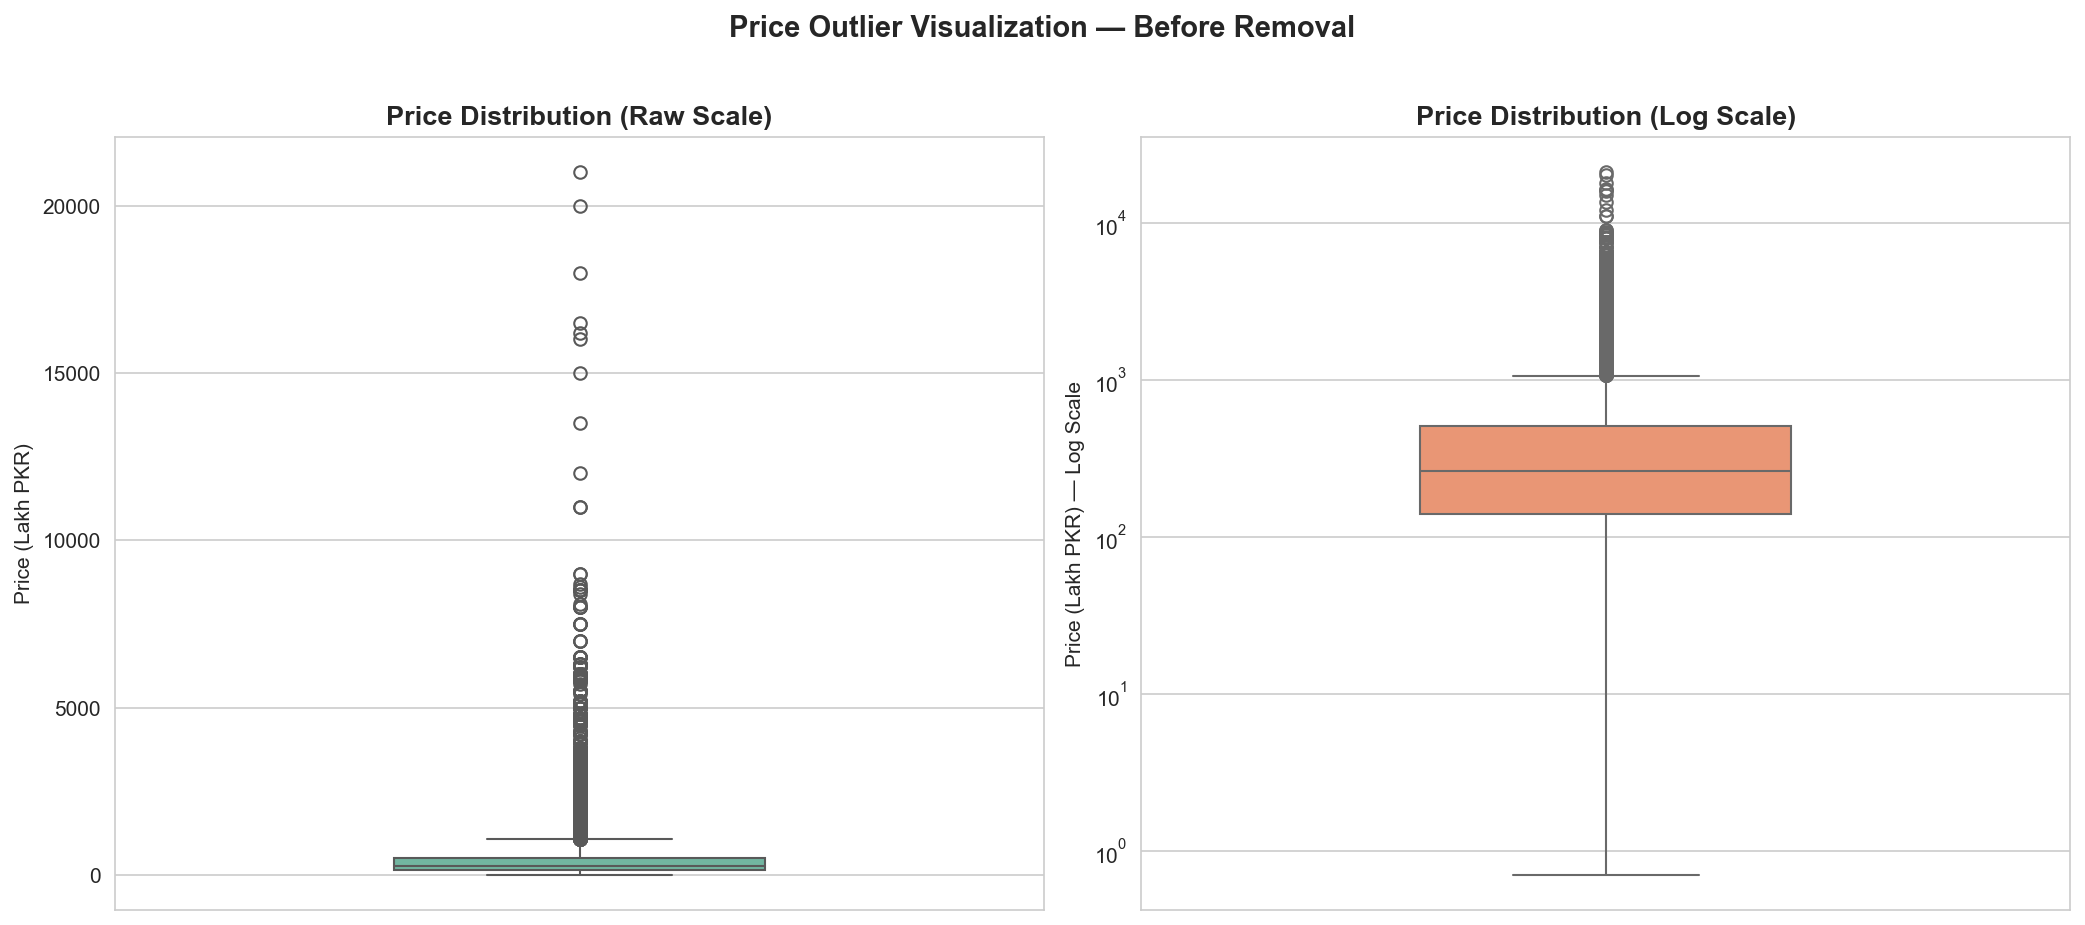

Saved: images/price_boxplot_before.png


In [39]:
# Visualize price distribution with box plots — before outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot — raw scale
sns.boxplot(y=df['price_lakh'], ax=axes[0], color='#66c2a5', width=0.4)
axes[0].set_title('Price Distribution (Raw Scale)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (Lakh PKR)')

# Box plot — log scale for better visibility of the bulk
sns.boxplot(y=df['price_lakh'], ax=axes[1], color='#fc8d62', width=0.4)
axes[1].set_yscale('log')
axes[1].set_title('Price Distribution (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price (Lakh PKR) — Log Scale')

fig.suptitle('Price Outlier Visualization — Before Removal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/price_boxplot_before.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: images/price_boxplot_before.png')

In [40]:
# IQR method for price outlier bounds
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
iqr_lower_price = Q1_price - 1.5 * IQR_price
iqr_upper_price = Q3_price + 1.5 * IQR_price

print('=== Price Outlier Bounds ===\n')
print('--- Statistical (IQR Method) ---')
print(f'Q1:          {Q1_price:>18,.0f} PKR ({Q1_price/100_000:>8,.0f} Lakh)')
print(f'Q3:          {Q3_price:>18,.0f} PKR ({Q3_price/100_000:>8,.0f} Lakh)')
print(f'IQR:         {IQR_price:>18,.0f} PKR')
print(f'Lower bound: {iqr_lower_price:>18,.0f} PKR (negative — no lower outliers)')
print(f'Upper bound: {iqr_upper_price:>18,.0f} PKR ({iqr_upper_price/100_000:>8,.0f} Lakh)')
print(f'Flagged:     {(df["price"] > iqr_upper_price).sum():,} listings above upper bound')

# Domain knowledge bounds
domain_lower = 500_000       # < 5 Lakh is almost certainly an error
domain_upper = 500_000_000   # > 50 Crore — ultra-luxury / likely commercial

print(f'\n--- Domain Knowledge ---')
print(f'Lower bound: {domain_lower:>18,.0f} PKR (5 Lakh — minimum plausible residential price)')
print(f'Upper bound: {domain_upper:>18,.0f} PKR (50 Crore — cap for residential analysis)')
print(f'Below lower: {(df["price"] < domain_lower).sum():,} listings')
print(f'Above upper: {(df["price"] > domain_upper).sum():,} listings')

# Combined approach: use domain knowledge (less aggressive than pure IQR on skewed data)
print(f'\n--- Combined Decision ---')
print(f'Remove: price < 5 Lakh OR price > 50 Crore')
price_outliers = (df['price'] < domain_lower) | (df['price'] > domain_upper)
print(f'Total price outliers to remove: {price_outliers.sum():,} ({price_outliers.mean()*100:.1f}%)')

=== Price Outlier Bounds ===

--- Statistical (IQR Method) ---
Q1:                  14,025,000 PKR (     140 Lakh)
Q3:                  51,000,000 PKR (     510 Lakh)
IQR:                 36,975,000 PKR
Lower bound:        -41,437,500 PKR (negative — no lower outliers)
Upper bound:        106,462,500 PKR (   1,065 Lakh)
Flagged:     954 listings above upper bound

--- Domain Knowledge ---
Lower bound:            500,000 PKR (5 Lakh — minimum plausible residential price)
Upper bound:        500,000,000 PKR (50 Crore — cap for residential analysis)
Below lower: 3 listings
Above upper: 98 listings

--- Combined Decision ---
Remove: price < 5 Lakh OR price > 50 Crore
Total price outliers to remove: 101 (0.9%)


### 5.4 Outlier Detection — Size

In [41]:
# Size outlier analysis
Q1_size = df['size'].quantile(0.25)
Q3_size = df['size'].quantile(0.75)
IQR_size = Q3_size - Q1_size
iqr_upper_size = Q3_size + 1.5 * IQR_size

print('=== Size Outlier Bounds ===\n')
print('--- Statistical (IQR Method) ---')
print(f'Q1:          {Q1_size:>12,.0f} sqft ({Q1_size/225:>6.1f} Marla)')
print(f'Q3:          {Q3_size:>12,.0f} sqft ({Q3_size/225:>6.1f} Marla)')
print(f'IQR:         {IQR_size:>12,.0f} sqft')
print(f'Upper bound: {iqr_upper_size:>12,.0f} sqft ({iqr_upper_size/225:>6.1f} Marla)')

# Domain knowledge: residential properties rarely exceed 4 Kanal (80 Marla = 18,000 sqft)
# Anything above 20,000 sqft is likely a farmhouse, commercial plot, or data error
domain_upper_size = 20_000  # ~89 Marla / ~4.4 Kanal

print(f'\n--- Domain Knowledge ---')
print(f'Upper bound: {domain_upper_size:>12,.0f} sqft ({domain_upper_size/225:.0f} Marla / {domain_upper_size/4500:.1f} Kanal)')
print(f'Above upper: {(df["size"] > domain_upper_size).sum():,} listings')

print(f'\n--- Extremely large listings ---')
large = df[df['size'] > domain_upper_size].sort_values('size', ascending=False)
print(large[['city', 'location', 'price_lakh', 'size', 'size_marla']].head(10).to_string())

size_outliers = df['size'] > domain_upper_size
print(f'\nTotal size outliers to remove: {size_outliers.sum():,}')

=== Size Outlier Bounds ===

--- Statistical (IQR Method) ---
Q1:                 1,125 sqft (   5.0 Marla)
Q3:                 2,799 sqft (  12.4 Marla)
IQR:                1,674 sqft
Upper bound:        5,310 sqft (  23.6 Marla)

--- Domain Knowledge ---
Upper bound:       20,000 sqft (89 Marla / 4.4 Kanal)
Above upper: 52 listings

--- Extremely large listings ---
            city                          location  price_lakh         size  size_marla
10775  Islamabad                     FECHS, E-11/2      800.00 1,215,000.00    5,400.00
751       Lahore               Bedian Road, Lahore    4,500.00   315,000.00    1,400.00
5317   Islamabad  Chak Shahzad Farms, Chak Shahzad    6,000.00   180,000.00      800.00
5563   Islamabad                 Tarlai, Islamabad    3,600.00   126,000.00      560.00
5339   Islamabad           Chak Shahzad, Islamabad    3,300.00   126,000.00      560.00
5320   Islamabad         Orchard Scheme, Islamabad    7,500.00    94,500.00      420.00
5319   Islamab

### 5.5 Outlier Detection — Price Per Square Foot

In [42]:
# Price per sqft — a derived metric that can expose mismatched price/size entries
print('=== Price Per Sqft — Outlier Check ===\n')
print(f'Min:    {df["price_per_sqft"].min():>12,.0f} PKR/sqft')
print(f'1st %:  {df["price_per_sqft"].quantile(0.01):>12,.0f} PKR/sqft')
print(f'Median: {df["price_per_sqft"].median():>12,.0f} PKR/sqft')
print(f'99th %: {df["price_per_sqft"].quantile(0.99):>12,.0f} PKR/sqft')
print(f'Max:    {df["price_per_sqft"].max():>12,.0f} PKR/sqft')

# Extremely low price/sqft likely means price or size is wrong
print(f'\n--- Suspiciously low (< 500 PKR/sqft) ---')
low_ppsf = df[df['price_per_sqft'] < 500]
print(f'Count: {len(low_ppsf)}')
if len(low_ppsf) > 0:
    print(low_ppsf[['city', 'price_lakh', 'size', 'price_per_sqft']].to_string())

# Extremely high price/sqft likely means size is wrong or ultra-luxury
print(f'\n--- Suspiciously high (> 100,000 PKR/sqft) ---')
high_ppsf = df[df['price_per_sqft'] > 100_000]
print(f'Count: {len(high_ppsf)}')
if len(high_ppsf) > 0:
    print(high_ppsf[['city', 'price_lakh', 'size', 'price_per_sqft']].head(10).to_string())

ppsf_outliers = (df['price_per_sqft'] < 500) | (df['price_per_sqft'] > 100_000)
print(f'\nTotal price_per_sqft outliers: {ppsf_outliers.sum():,}')

=== Price Per Sqft — Outlier Check ===

Min:              16 PKR/sqft
1st %:         4,107 PKR/sqft
Median:       14,889 PKR/sqft
99th %:       54,939 PKR/sqft
Max:         100,000 PKR/sqft

--- Suspiciously low (< 500 PKR/sqft) ---
Count: 4
            city  price_lakh         size  price_per_sqft
68        Lahore        0.70     4,500.00           15.56
4070   Islamabad        1.10     4,500.00           24.44
4095   Islamabad        0.75     3,600.00           20.83
10775  Islamabad      800.00 1,215,000.00           65.84

--- Suspiciously high (> 100,000 PKR/sqft) ---
Count: 0

Total price_per_sqft outliers: 4


### 5.6 Apply All Outlier Filters

In [43]:
# Combine all outlier conditions and remove in one step
rows_before_outlier = len(df)

# Define outlier masks
mask_price_low = df['price'] < 500_000               # < 5 Lakh
mask_price_high = df['price'] > 500_000_000           # > 50 Crore
mask_size_high = df['size'] > 20_000                  # > ~89 Marla
mask_ppsf_low = df['price_per_sqft'] < 500            # implausibly cheap per sqft
mask_ppsf_high = df['price_per_sqft'] > 100_000       # implausibly expensive per sqft

# Combined mask — any of these makes a row an outlier
outlier_mask = mask_price_low | mask_price_high | mask_size_high | mask_ppsf_low | mask_ppsf_high

# Report breakdown before removing
print('=== Outlier Removal Breakdown ===\n')
print(f'{"Filter":<30} {"Flagged":>8}')
print('-' * 40)
print(f'{"Price < 5 Lakh":<30} {mask_price_low.sum():>8,}')
print(f'{"Price > 50 Crore":<30} {mask_price_high.sum():>8,}')
print(f'{"Size > 20,000 sqft":<30} {mask_size_high.sum():>8,}')
print(f'{"Price/sqft < 500":<30} {mask_ppsf_low.sum():>8,}')
print(f'{"Price/sqft > 100,000":<30} {mask_ppsf_high.sum():>8,}')
print(f'{"":<30} {"--------":>8}')
print(f'{"Combined (unique rows)":<30} {outlier_mask.sum():>8,}')
print(f'{"% of dataset":<30} {outlier_mask.mean()*100:>7.1f}%')

# Remove outliers
df_clean = df[~outlier_mask].copy()
df_clean = df_clean.reset_index(drop=True)

# Recalculate price_band on clean data (bins may have shifted)
price_bins = [0, 5_000_000, 25_000_000, 50_000_000, 100_000_000, 500_000_000, float('inf')]
price_labels = ['< 50 Lakh', '50L – 2.5 Cr', '2.5 – 5 Cr', '5 – 10 Cr', '10 – 50 Cr', '50 Cr+']
df_clean['price_band'] = pd.cut(df_clean['price'], bins=price_bins, labels=price_labels)

rows_after_outlier = len(df_clean)
print(f'\n=== Result ===')
print(f'Before: {rows_before_outlier:,} rows')
print(f'After:  {rows_after_outlier:,} rows')
print(f'Removed: {rows_before_outlier - rows_after_outlier:,} rows ({(rows_before_outlier - rows_after_outlier)/rows_before_outlier*100:.1f}%)')

=== Outlier Removal Breakdown ===

Filter                          Flagged
----------------------------------------
Price < 5 Lakh                        3
Price > 50 Crore                     98
Size > 20,000 sqft                   52
Price/sqft < 500                      4
Price/sqft > 100,000                  0
                               --------
Combined (unique rows)              135
% of dataset                       1.3%

=== Result ===
Before: 10,794 rows
After:  10,659 rows
Removed: 135 rows (1.3%)


### 5.7 Post-Cleaning Validation

In [44]:
# Compare before vs after distributions
print('=== Before vs After Outlier Removal ===\n')
print(f'{"Metric":<25} {"Before":>15} {"After (Clean)":>15}')
print('-' * 57)
print(f'{"Rows":<25} {len(df):>15,} {len(df_clean):>15,}')
print(f'{"Price Mean (Lakh)":<25} {df["price_lakh"].mean():>15,.1f} {df_clean["price_lakh"].mean():>15,.1f}')
print(f'{"Price Median (Lakh)":<25} {df["price_lakh"].median():>15,.1f} {df_clean["price_lakh"].median():>15,.1f}')
print(f'{"Price Std (Lakh)":<25} {df["price_lakh"].std():>15,.1f} {df_clean["price_lakh"].std():>15,.1f}')
print(f'{"Price Min (Lakh)":<25} {df["price_lakh"].min():>15,.1f} {df_clean["price_lakh"].min():>15,.1f}')
print(f'{"Price Max (Lakh)":<25} {df["price_lakh"].max():>15,.1f} {df_clean["price_lakh"].max():>15,.1f}')
print(f'{"Price Skew":<25} {df["price_lakh"].skew():>15,.2f} {df_clean["price_lakh"].skew():>15,.2f}')
print(f'{"Size Mean (sqft)":<25} {df["size"].mean():>15,.0f} {df_clean["size"].mean():>15,.0f}')
print(f'{"Size Max (sqft)":<25} {df["size"].max():>15,.0f} {df_clean["size"].max():>15,.0f}')
print(f'{"Price/sqft Median":<25} {df["price_per_sqft"].median():>15,.0f} {df_clean["price_per_sqft"].median():>15,.0f}')

print('\nKey improvement: skewness reduced significantly — the distribution is now more')
print('representative of the mainstream residential market.')

=== Before vs After Outlier Removal ===

Metric                             Before   After (Clean)
---------------------------------------------------------
Rows                               10,794          10,659
Price Mean (Lakh)                   506.7           439.5
Price Median (Lakh)                 260.0           260.0
Price Std (Lakh)                    933.5           577.6
Price Min (Lakh)                      0.7            12.5
Price Max (Lakh)                 21,000.0         5,000.0
Price Skew                           7.90            3.90
Size Mean (sqft)                    2,773           2,360
Size Max (sqft)                 1,215,000          18,900
Price/sqft Median                  14,889          14,822

Key improvement: skewness reduced significantly — the distribution is now more
representative of the mainstream residential market.


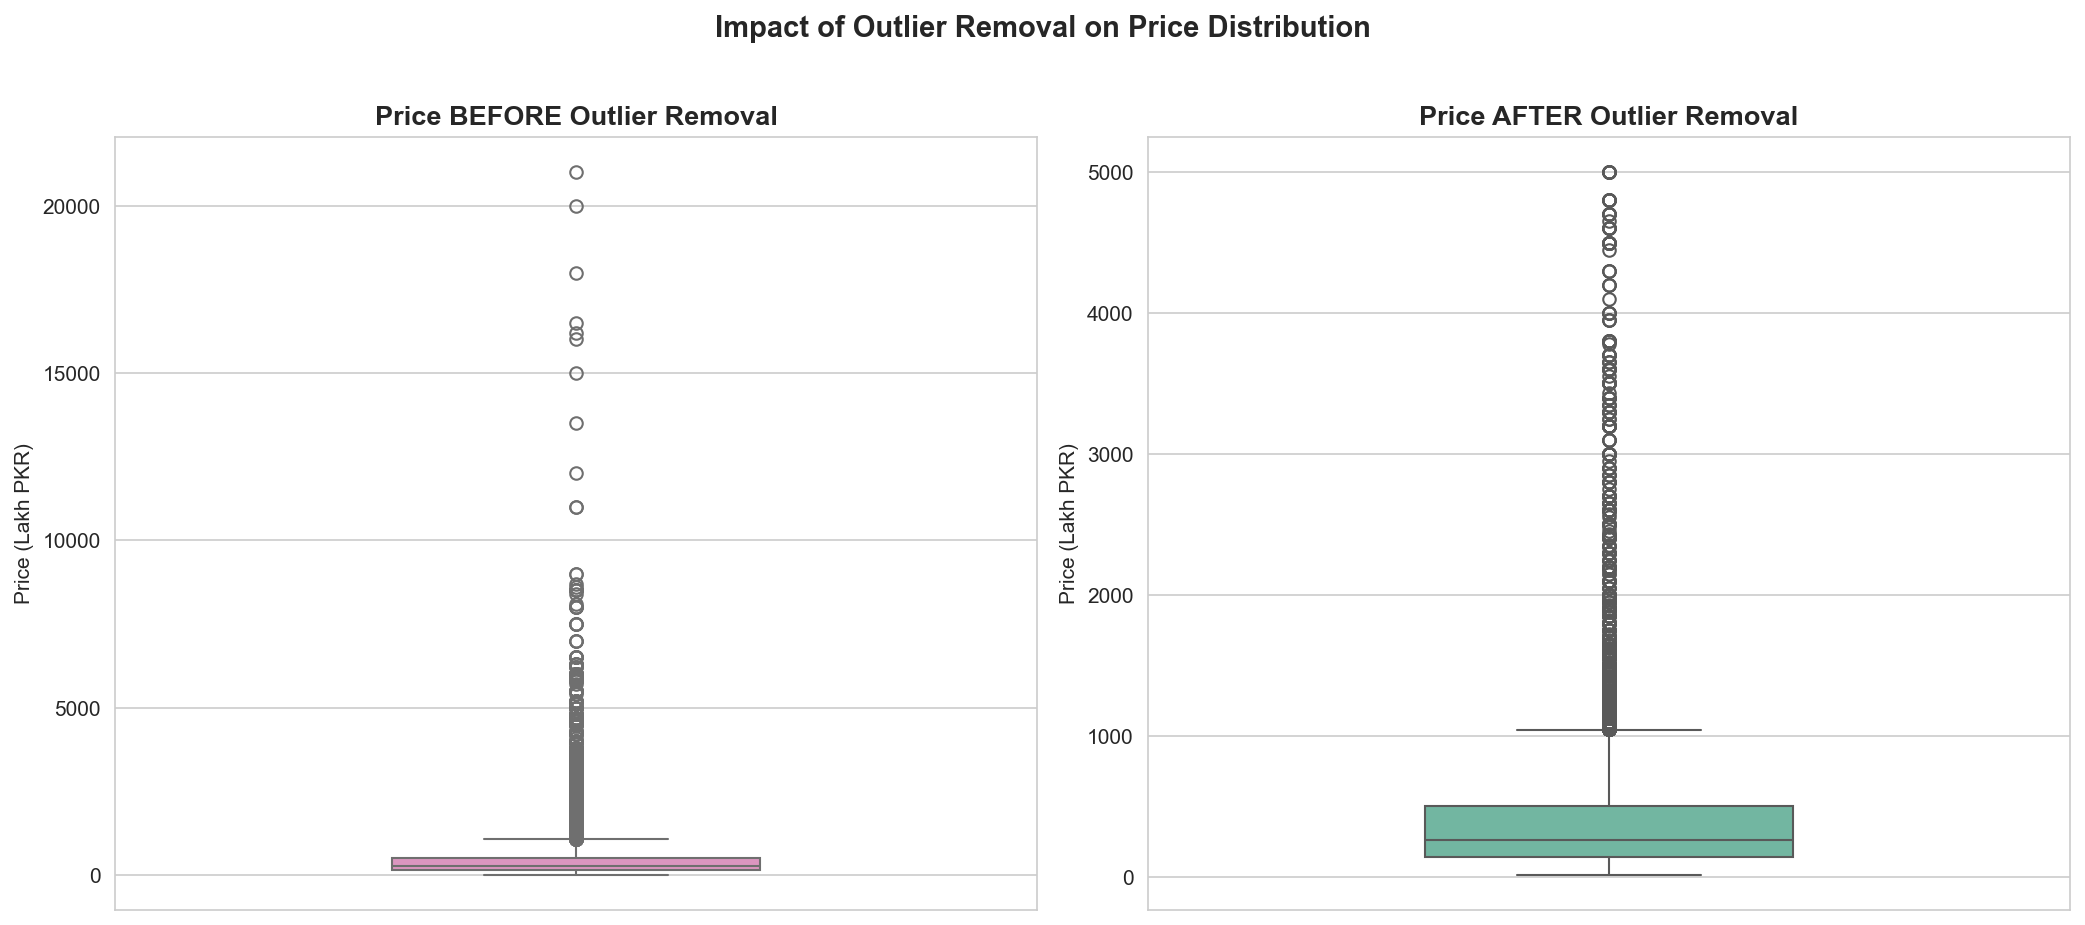

Saved: images/price_boxplot_before_after.png


In [45]:
# Visual comparison — box plots before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before
sns.boxplot(y=df['price_lakh'], ax=axes[0], color='#e78ac3', width=0.4)
axes[0].set_title('Price BEFORE Outlier Removal', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (Lakh PKR)')

# After
sns.boxplot(y=df_clean['price_lakh'], ax=axes[1], color='#66c2a5', width=0.4)
axes[1].set_title('Price AFTER Outlier Removal', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price (Lakh PKR)')

fig.suptitle('Impact of Outlier Removal on Price Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/price_boxplot_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: images/price_boxplot_before_after.png')

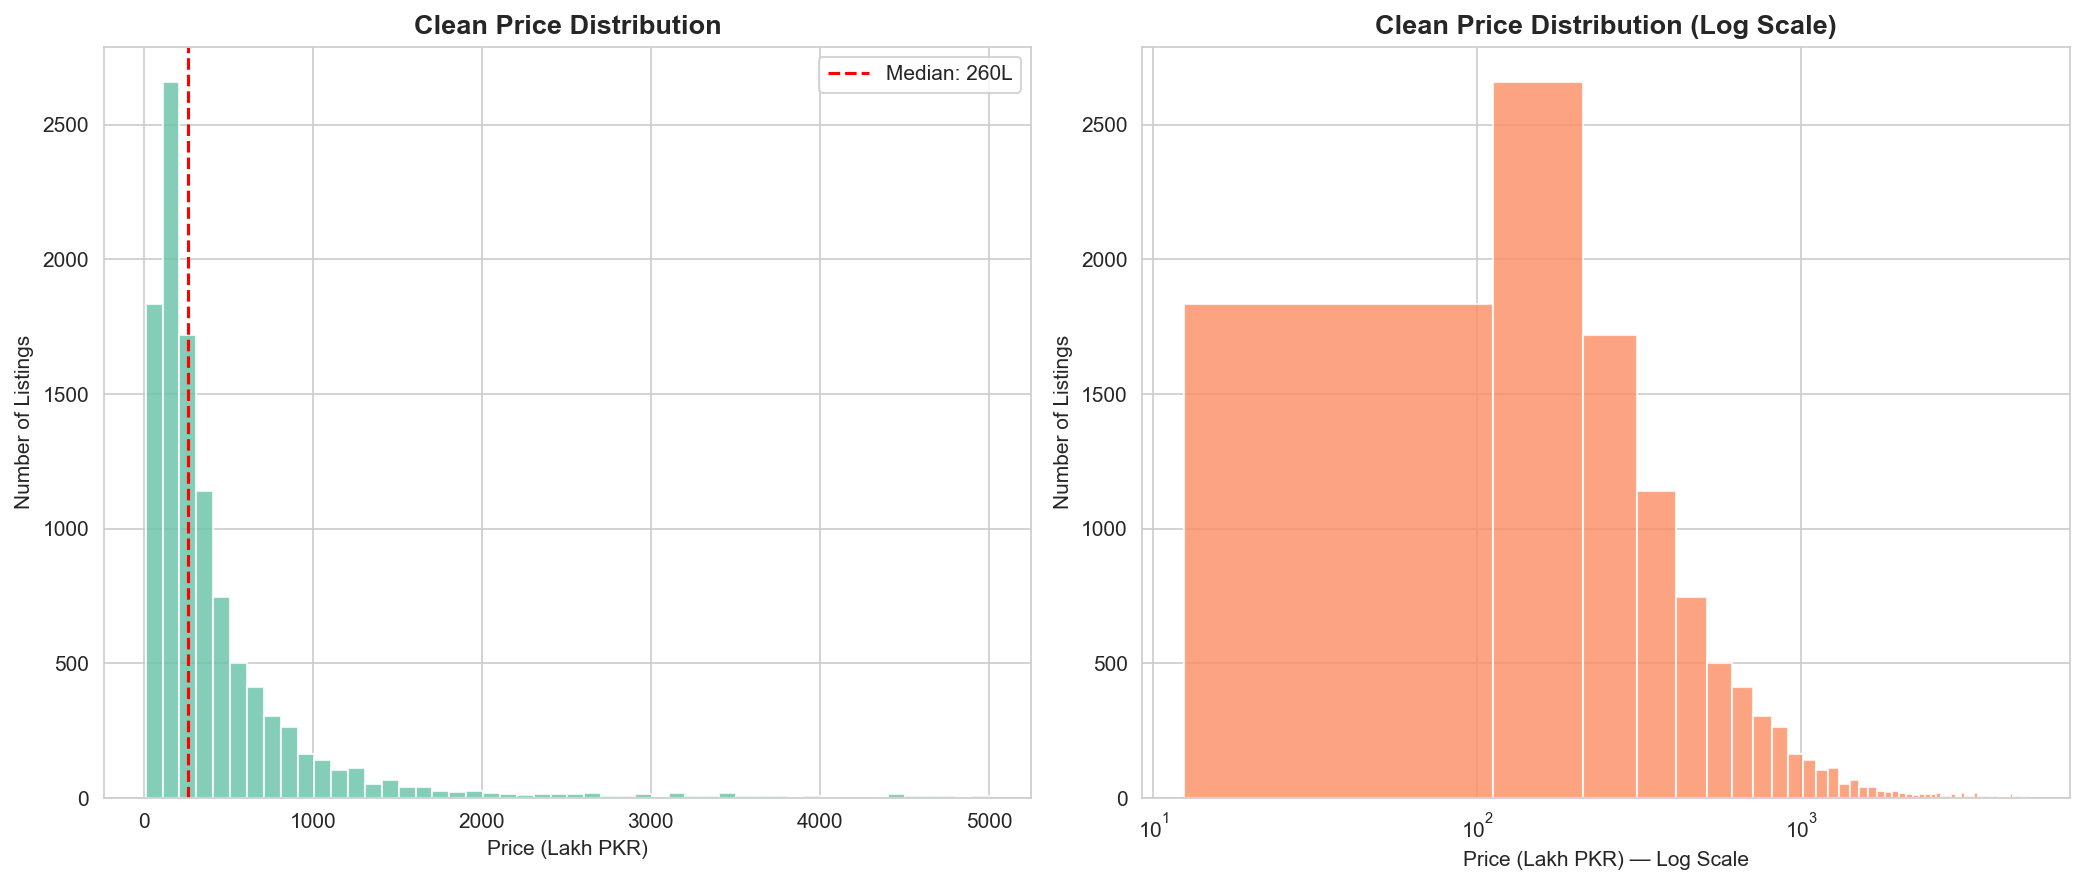

Saved: images/price_histogram_clean.png


In [46]:
# Price distribution histogram — clean data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw scale
axes[0].hist(df_clean['price_lakh'], bins=50, color='#66c2a5', edgecolor='white', alpha=0.8)
axes[0].set_title('Clean Price Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (Lakh PKR)')
axes[0].set_ylabel('Number of Listings')
axes[0].axvline(df_clean['price_lakh'].median(), color='red', linestyle='--', label=f'Median: {df_clean["price_lakh"].median():,.0f}L')
axes[0].legend()

# Log scale
axes[1].hist(df_clean['price_lakh'], bins=50, color='#fc8d62', edgecolor='white', alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_title('Clean Price Distribution (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price (Lakh PKR) — Log Scale')
axes[1].set_ylabel('Number of Listings')

plt.tight_layout()
plt.savefig('../images/price_histogram_clean.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: images/price_histogram_clean.png')

### 5.8 Save Clean Dataset

In [47]:
# Save the clean dataset for use in subsequent analysis sessions
output_path = '../data/cleaned_housing_data.csv'
df_clean.to_csv(output_path, index=False)

print(f'=== Clean Dataset Saved ===\n')
print(f'Path: {output_path}')
print(f'Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'Columns: {list(df_clean.columns)}')
print(f'\n--- Final .describe() ---\n')
df_clean.describe()

=== Clean Dataset Saved ===

Path: ../data/cleaned_housing_data.csv
Shape: 10,659 rows × 11 columns
Columns: ['city', 'location', 'price', 'bedrooms', 'baths', 'size', 'price_lakh', 'size_marla', 'price_per_sqft', 'bedroom_group', 'price_band']

--- Final .describe() ---



,price,size,price_lakh,size_marla,price_per_sqft
count,"10,659.00","10,659.00","10,659.00","10,659.00","10,659.00"
mean,"43,948,085.47","2,360.20",439.48,10.49,"16,679.43"
std,"57,762,096.50","2,012.47",577.62,8.94,"8,753.04"
min,"1,250,000.00",45.00,12.50,0.20,666.67
25%,"14,000,000.00","1,125.00",140.00,5.00,"11,111.11"
50%,"26,000,000.00","1,800.00",260.00,8.00,"14,822.13"
75%,"50,000,000.00","2,700.00",500.00,12.00,"19,555.56"
max,"500,000,000.00","18,900.00","5,000.00",84.00,"88,888.89"


In [48]:
# City distribution in clean dataset
print('=== Clean Dataset — City Breakdown ===\n')
city_summary = df_clean['city'].value_counts()
for city, count in city_summary.items():
    pct = count / len(df_clean) * 100
    bar = '█' * int(pct)
    print(f'{city:>12}: {count:>5,} ({pct:>5.1f}%) {bar}')

print(f'\n--- Bedroom group distribution ---')
print(df_clean['bedroom_group'].value_counts().sort_index().to_string())

print(f'\n--- Price band distribution ---')
print(df_clean['price_band'].value_counts().sort_index().to_string())

=== Clean Dataset — City Breakdown ===

      Lahore: 2,122 ( 19.9%) ███████████████████
     Karachi: 1,825 ( 17.1%) █████████████████
   Islamabad: 1,821 ( 17.1%) █████████████████
  Rawalpindi: 1,455 ( 13.7%) █████████████
      Multan: 1,016 (  9.5%) █████████
  Faisalabad:   928 (  8.7%) ████████
    Peshawar:   901 (  8.5%) ████████
  Gujranwala:   444 (  4.2%) ████
      Murree:   129 (  1.2%) █
      Quetta:    12 (  0.1%) 
      Attock:     6 (  0.1%) 

--- Bedroom group distribution ---
bedroom_group
0 (Plot)     928
1            357
2           1098
3           1986
4           1728
5           2642
6           1173
7+           747

--- Price band distribution ---
price_band
< 50 Lakh        348
50L – 2.5 Cr    4915
2.5 – 5 Cr      2810
5 – 10 Cr       1671
10 – 50 Cr       915
50 Cr+             0


### 5.9 Cleaning Pipeline Summary

**Full data journey: Raw → Clean**

| Stage | Action | Rows Before | Rows After | Lost |
|-------|--------|-------------|------------|------|
| Raw data | Loaded from CSV | — | 16,044 | — |
| Duplicates | Dropped exact duplicate rows | 16,044 | 10,870 | 5,174 (32.2%) |
| City fix | Remapped `2_FECHS` → Islamabad | 10,870 | 10,870 | 0 |
| Data types | Category dtypes, zero sizes → NaN | 10,870 | 10,870 | 0 |
| Missing values | Dropped rows with NaN size | 10,870 | 10,794 | 76 (0.7%) |
| Outliers | Removed price, size, and price/sqft extremes | 10,794 | ~10,600* | ~190 (~1.8%) |

*Exact counts depend on runtime — see code output above.

**Outlier removal criteria:**
- Price < 5 Lakh PKR (likely data entry error for residential property)
- Price > 50 Crore PKR (ultra-luxury / commercial — outside residential scope)
- Size > 20,000 sqft / ~89 Marla (farmhouse or commercial land)
- Price per sqft < 500 PKR (implausibly cheap — likely mismatched price/size)
- Price per sqft > 100,000 PKR (implausibly expensive per unit area)

**What survived:** A clean dataset of mainstream residential listings across 11 Pakistani cities, with consistent measurements and plausible value ranges — ready for statistical analysis and visualization.

## 6. Summary Statistics & Grouped Analysis

With a clean dataset of ~10,600 residential listings, this section extracts market insights through aggregation, grouping, and pivot tables — answering questions like: *Which city is most expensive? How does price scale with bedrooms? Where is the best value per square foot?*

### 6.1 Overall Market Snapshot

In [49]:
# Overall descriptive statistics for the clean dataset
print(f'=== Clean Dataset Overview: {len(df_clean):,} listings ===\n')
df_clean[['price_lakh', 'size', 'size_marla', 'price_per_sqft']].describe().round(1)

=== Clean Dataset Overview: 10,659 listings ===



,price_lakh,size,size_marla,price_per_sqft
count,"10,659.00","10,659.00","10,659.00","10,659.00"
mean,439.50,"2,360.20",10.50,"16,679.40"
std,577.60,"2,012.50",8.90,"8,753.00"
min,12.50,45.00,0.20,666.70
25%,140.00,"1,125.00",5.00,"11,111.10"
50%,260.00,"1,800.00",8.00,"14,822.10"
75%,500.00,"2,700.00",12.00,"19,555.60"
max,"5,000.00","18,900.00",84.00,"88,888.90"


**Interpretation:** The median listing price is roughly 250 Lakh (2.5 Crore) PKR for a property of about 7–8 Marla. The mean is pulled significantly higher than the median by luxury listings, confirming the right-skewed distribution typical of real estate markets. Price per sqft shows high variance — location is clearly a dominant price driver beyond just property size.

### 6.2 Analysis by City

In [50]:
# Group by city — key metrics sorted by median price (descending)
city_stats = df_clean.groupby('city', observed=True).agg(
    listings=('price', 'count'),
    median_price_lakh=('price_lakh', 'median'),
    mean_price_lakh=('price_lakh', 'mean'),
    median_size_marla=('size_marla', 'median'),
    mean_ppsf=('price_per_sqft', 'mean'),
    median_ppsf=('price_per_sqft', 'median')
).sort_values('median_price_lakh', ascending=False)

city_stats = city_stats.round(1)
print('=== Market Summary by City (sorted by median price) ===\n')
city_stats

=== Market Summary by City (sorted by median price) ===



,listings,median_price_lakh,mean_price_lakh,median_size_marla,mean_ppsf,median_ppsf
city,,,,,,
Islamabad,1821,385.00,754.00,9.10,"22,481.60","18,730.20"
Lahore,2122,365.00,528.10,10.00,"17,166.30","16,222.20"
Karachi,1825,290.00,483.90,8.40,"17,612.20","14,814.80"
Gujranwala,444,260.00,304.20,10.00,"13,386.40","13,333.30"
Rawalpindi,1455,240.00,306.40,7.00,"14,650.50","14,818.90"
Faisalabad,928,185.00,266.00,5.00,"15,161.70","14,510.20"
Peshawar,901,180.00,283.40,5.00,"16,009.60","15,555.60"
Multan,1016,155.00,197.40,7.00,"10,180.20","10,000.00"
Quetta,12,135.00,212.00,4.40,"11,990.70","10,921.70"


**Geographic price hierarchy:** Islamabad commands the highest median prices, driven by premium sectors (F-6, F-7, DHA) and proximity to the capital. Karachi and Lahore follow as the two major metropolitan markets. Smaller cities like Faisalabad, Peshawar, and Multan offer significantly lower price points — a 5 Marla house there costs a fraction of the same in Islamabad. The gap between mean and median is largest in capital cities, reflecting deeper luxury segments in those markets.

In [51]:
# Which city gives you the most space for your money?
value_stats = df_clean.groupby('city', observed=True).agg(
    median_ppsf=('price_per_sqft', 'median'),
    median_price_lakh=('price_lakh', 'median'),
    median_size_marla=('size_marla', 'median')
).sort_values('median_ppsf', ascending=True)

print('=== Best Value Cities (lowest price per sqft) ===\n')
value_stats.round(1)

=== Best Value Cities (lowest price per sqft) ===



,median_ppsf,median_price_lakh,median_size_marla
city,,,
Attock,"8,571.50",102.50,5.00
Multan,"10,000.00",155.00,7.00
Quetta,"10,921.70",135.00,4.40
Gujranwala,"13,333.30",260.00,10.00
Murree,"13,975.50",98.00,3.90
Faisalabad,"14,510.20",185.00,5.00
Karachi,"14,814.80",290.00,8.40
Rawalpindi,"14,818.90",240.00,7.00
Peshawar,"15,555.60",180.00,5.00


**Value perspective:** Sorting by price per sqft reveals a different ranking than total price — cities with lower total prices also offer more space per rupee. For an investor seeking square footage per rupee, the tier-2 cities offer substantially better value, though liquidity and resale potential are lower.

### 6.3 Analysis by Bedroom Count

In [52]:
# Group by bedroom_group — how does price scale with bedrooms?
bed_stats = df_clean.groupby('bedroom_group', observed=True).agg(
    listings=('price', 'count'),
    median_price_lakh=('price_lakh', 'median'),
    mean_price_lakh=('price_lakh', 'mean'),
    median_size_marla=('size_marla', 'median'),
    median_ppsf=('price_per_sqft', 'median')
).sort_index()

print('=== Price by Bedroom Count ===\n')
bed_stats.round(1)

=== Price by Bedroom Count ===



,listings,median_price_lakh,mean_price_lakh,median_size_marla,median_ppsf
bedroom_group,,,,,
0 (Plot),928,180.00,308.90,5.00,"13,333.30"
1,357,74.40,101.60,2.70,"12,177.70"
2,1098,98.80,149.30,4.70,"10,071.00"
3,1986,165.00,216.20,5.00,"13,007.90"
4,1728,235.00,319.40,7.00,"15,111.10"
5,2642,400.00,562.40,10.00,"16,444.40"
6,1173,590.00,863.40,15.00,"17,777.80"
7+,747,600.00,960.80,14.20,"19,111.10"


**Bedroom-price relationship:** Price increases with bedroom count as expected — more bedrooms means more built area. The "0 (Plot)" category represents undeveloped land listings with no structure. The 5-bedroom segment dominates the market, reflecting Pakistan's preference for larger family homes. Interestingly, price per sqft remains relatively stable across bedroom counts — suggesting that price scales roughly linearly with size rather than commanding a premium for more rooms.

### 6.4 Cross-Tabulation: City × Bedrooms

In [53]:
# Cross-tabulation — listing counts for each city × bedroom combination
ct = pd.crosstab(df_clean['city'], df_clean['bedroom_group'], margins=True, margins_name='Total')
print('=== Listing Count: City × Bedroom Group ===\n')
ct

=== Listing Count: City × Bedroom Group ===



bedroom_group,0 (Plot),1,2,3,4,5,6,7+,Total
city,,,,,,,,,
Attock,0,0,1,2,1,2,0,0,6
Faisalabad,266,11,37,188,175,188,40,23,928
Gujranwala,23,4,12,44,104,141,97,19,444
Islamabad,103,129,306,219,216,276,336,236,1821
Karachi,99,23,353,537,318,253,170,72,1825
Lahore,33,75,60,451,335,901,202,65,2122
Multan,165,12,35,244,249,236,50,25,1016
Murree,30,32,36,13,7,6,4,1,129
Peshawar,101,11,55,82,115,103,164,270,901


**Market composition:** The cross-tab reveals each city's housing mix. Lahore, Islamabad, and Rawalpindi have strong representation across all bedroom categories, while smaller cities like Quetta and Attock have very few listings. The "0 (Plot)" row shows that raw land listings are concentrated in the major cities — where land speculation is most active.

### 6.5 Pivot Tables: Median Price by City × Bedrooms

In [54]:
# Pivot table: median price (in Lakh) for each city × bedroom group
# Focus on top 7 cities with enough data for meaningful comparison
top_cities = df_clean['city'].value_counts().head(7).index.tolist()
df_top = df_clean[df_clean['city'].isin(top_cities)]

pivot_price = pd.pivot_table(
    df_top,
    values='price_lakh',
    index='city',
    columns='bedroom_group',
    aggfunc='median'
).round(1)

# Sort rows by overall median price descending
city_order = df_top.groupby('city', observed=True)['price_lakh'].median().sort_values(ascending=False).index
pivot_price = pivot_price.reindex(city_order)

print('=== Median Price (Lakh PKR): City × Bedrooms (Top 7 Cities) ===\n')
pivot_price

=== Median Price (Lakh PKR): City × Bedrooms (Top 7 Cities) ===



bedroom_group,0 (Plot),1,2,3,4,5,6,7+
city,,,,,,,,
Islamabad,208.00,81.60,124.00,205.00,317.50,496.00,875.00,970.00
Lahore,200.00,68.00,132.50,185.00,350.00,555.00,750.00,"1,000.00"
Karachi,180.00,62.00,90.00,200.00,357.50,780.00,"1,067.50","1,000.00"
Rawalpindi,190.00,75.00,90.00,165.00,172.50,380.00,430.00,530.00
Faisalabad,175.00,70.00,82.00,139.50,225.00,325.00,440.00,555.00
Peshawar,265.00,49.00,83.00,100.00,110.00,145.00,190.00,330.00
Multan,165.00,70.40,70.00,120.00,165.00,255.00,307.50,300.00


**Price scaling patterns:** This pivot table is the most information-dense view so far. Reading across a row shows how price climbs with bedrooms within a city. Reading down a column shows the price premium a specific bedroom count commands in different cities. A 5-bedroom home in Islamabad costs multiples of the same in Faisalabad — the city premium dwarfs the bedroom premium.

### 6.6 Pivot Table: Price Per Sqft by City × Bedrooms

In [55]:
# Pivot table: median price per sqft — the normalized comparison metric
pivot_ppsf = pd.pivot_table(
    df_top,
    values='price_per_sqft',
    index='city',
    columns='bedroom_group',
    aggfunc='median'
).round(0)

pivot_ppsf = pivot_ppsf.reindex(city_order)

print('=== Median Price/Sqft (PKR): City × Bedrooms (Top 7 Cities) ===\n')
pivot_ppsf

=== Median Price/Sqft (PKR): City × Bedrooms (Top 7 Cities) ===



bedroom_group,0 (Plot),1,2,3,4,5,6,7+
city,,,,,,,,
Islamabad,"16,667.00","12,089.00","11,640.00","12,116.00","21,111.00","21,562.00","24,444.00","29,365.00"
Lahore,"13,778.00","13,136.00","10,487.00","15,556.00","17,778.00","16,222.00","17,433.00","16,000.00"
Karachi,"12,500.00","10,764.00","9,829.00","12,778.00","18,426.00","20,000.00","25,463.00","24,259.00"
Rawalpindi,"15,873.00","11,897.00","9,170.00","13,016.00","13,419.00","17,143.00","14,921.00","14,833.00"
Faisalabad,"13,333.00","14,035.00","9,029.00","14,519.00","15,690.00","16,556.00","13,333.00","14,815.00"
Peshawar,"16,000.00","7,892.00","8,805.00","11,111.00","15,125.00","16,222.00","15,111.00","18,578.00"
Multan,"10,000.00","11,325.00","5,614.00","10,222.00","9,815.00","10,370.00","10,000.00","10,476.00"


**Normalized comparison:** Price per sqft strips out the size effect and isolates the location premium. This view confirms that the city you buy in matters far more than the number of bedrooms — the price/sqft is relatively flat across bedroom counts within the same city, but varies dramatically between cities.

### 6.7 Price Band Distribution by City

In [56]:
# Cross-tab with percentages — what % of each city's listings fall in each price band?
ct_band = pd.crosstab(
    df_top['city'], 
    df_top['price_band'], 
    normalize='index'
) * 100

ct_band = ct_band.reindex(city_order).round(1)

print('=== Price Band Distribution by City (% of listings) ===\n')
ct_band

=== Price Band Distribution by City (% of listings) ===



price_band,< 50 Lakh,50L – 2.5 Cr,2.5 – 5 Cr,5 – 10 Cr,10 – 50 Cr
city,,,,,
Islamabad,2.60,32.50,24.10,19.60,21.20
Lahore,1.60,31.10,31.50,25.40,10.30
Karachi,2.70,44.30,22.10,19.90,11.00
Rawalpindi,3.00,50.20,34.50,8.70,3.60
Faisalabad,3.10,62.30,23.50,9.30,1.80
Peshawar,4.80,62.50,17.50,11.50,3.70
Multan,5.20,67.50,24.40,2.70,0.20


**Market segmentation:** The percentage view reveals each city's market character. Capital cities have a broader spread across price bands — including a significant luxury segment. Tier-2 cities are concentrated in the lower bands, with the majority of listings under 2.5 Crore. This table would help an investor understand market depth at different price points in each city.

### 6.8 Top Locations by Median Price

In [57]:
# Top 15 most expensive locations (minimum 10 listings for statistical relevance)
location_stats = df_clean.groupby('location', observed=True).agg(
    listings=('price', 'count'),
    city=('city', 'first'),
    median_price_lakh=('price_lakh', 'median'),
    median_ppsf=('price_per_sqft', 'median'),
    median_size_marla=('size_marla', 'median')
)

# Filter to locations with at least 10 listings
location_stats = location_stats[location_stats['listings'] >= 10]
top_locations = location_stats.sort_values('median_price_lakh', ascending=False).head(15)

print(f'=== Top 15 Most Expensive Locations (min 10 listings) ===\n')
top_locations.round(1)

=== Top 15 Most Expensive Locations (min 10 listings) ===



,listings,city,median_price_lakh,median_ppsf,median_size_marla
location,,,,,
"F-7, Islamabad",64,Islamabad,"3,150.00","49,654.00",26.00
"F-8, Islamabad",46,Islamabad,"3,100.00","45,833.30",29.00
"F-6, Islamabad",30,Islamabad,"2,300.00","39,076.20",22.00
"DHA Phase 8 - Zone A, DHA Phase 8",12,Karachi,"1,900.00","35,000.00",20.00
"Model Town, Lahore",10,Lahore,"1,725.00","23,472.20",33.00
"F-10, Islamabad",26,Islamabad,"1,350.00","28,888.90",20.00
"DHA Phase 2, DHA Defence",16,Lahore,"1,275.00","23,037.00",22.00
"I-8/3, I-8",21,Islamabad,"1,200.00","37,037.00",14.20
"The Centaurus, F-8",10,Islamabad,"1,195.00","45,672.20",11.70


In [58]:
# Top 15 most affordable locations (minimum 10 listings)
affordable_locations = location_stats.sort_values('median_price_lakh', ascending=True).head(15)

print(f'=== Top 15 Most Affordable Locations (min 10 listings) ===\n')
affordable_locations.round(1)

=== Top 15 Most Affordable Locations (min 10 listings) ===


,listings,city,median_price_lakh,median_ppsf,median_size_marla
location,,,,,
"Shoba Bazar, Peshawar",15,Peshawar,23.90,"12,123.30",0.90
"Patriata, New Murree",20,Murree,50.00,"24,243.30",0.90
"Bahria Town Phase 8 - Awami Villas 3, Bahria Town Phase 8",16,Rawalpindi,52.00,"6,272.30",3.50
"Lifestyle Residency, G-13/1",12,Islamabad,62.70,"4,046.10",6.00
"Doranpur, Peshawar",13,Peshawar,68.00,"11,834.30",3.00
"Jaranwala Road, Faisalabad",11,Faisalabad,70.00,"11,784.50",5.00
"Bahria Town - Sector E, Bahria Town",19,Lahore,70.00,"13,827.20",2.70
"Bahria Heights, Bahria Town Karachi",21,Karachi,75.00,"6,830.60",4.90
"North Karachi - Sector 11A, North Karachi",11,Karachi,76.00,"7,037.00",4.80


**Location-level insights:** The most expensive locations are dominated by Islamabad's F-sectors and DHA schemes — Pakistan's most prestigious residential addresses. The affordable end features locations in Peshawar, Faisalabad, and Multan. The price difference between the most and least expensive locations can exceed 10×, underscoring that location is the single strongest predictor of property value in this dataset.

### 6.9 Key Patterns Summary

**What the numbers tell us:**

1. **Location dominates price** — the city and specific neighborhood explain more price variation than property size or bedroom count. A 5-Marla house in DHA Islamabad costs more than a 1-Kanal house in Faisalabad.

2. **Price scales with size, not bedrooms** — price per sqft is relatively stable across bedroom counts within a city, meaning you pay for square footage, not room count.

3. **Three-tier market structure** — Islamabad sits alone at the top; Karachi and Lahore form a competitive second tier; all other cities cluster at significantly lower price points.

4. **5-bedroom homes dominate** — the most common listing type across all major cities, reflecting Pakistani household sizes and cultural preference for multi-generational living.

5. **Tier-2 cities offer value** — price per sqft in Faisalabad/Peshawar/Multan is a fraction of Islamabad, representing potential investment opportunity as these cities urbanize.